In [ ]:
# Dipendenze gestite via requirements.txt
# pip install -r requirements.txt

In [ ]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aggiunge la root del repo al path (per importare config/)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Mount Drive se siamo su Colab
def is_colab():
    return "COLAB_RELEASE_TAG" in os.environ or os.path.exists("/content")

if is_colab():
    from google.colab import drive
    drive.mount('/content/drive')

from config.paths import get_base_path, is_colab


# carica file

In [ ]:
# ============================================================
# CONFIGURAZIONE PARTITA — modifica solo questa sezione
# ============================================================
SEASON          = "2025-2026"
compare_both_teams = True
write_files     = True

# Nomi delle squadre
sq1 = "Decimo"
sq2 = "JVC"

# Path dei file Excel relativi alla cartella base della stagione
# (copialo da config/matches.csv)
filename1 = "(POR) jvc - decimo 3-1+1/[decimo] jvc-decimo.xlsx"
filename2 = "(POR) jvc - decimo 3-1+1/[jvc] jvc-decimo.xlsx"

# ============================================================
# Costruzione path assoluti
# ============================================================
from config.paths import build_base_path

base = build_base_path(season=SEASON)
file_path1 = str(base / filename1)
file_path2 = str(base / filename2)

# Caricamento DataFrame
try:
    if compare_both_teams:
        df1 = pd.read_excel(file_path1, skiprows=1)
        df2 = pd.read_excel(file_path2, skiprows=1)
    else:
        df = pd.read_excel(file_path1, skiprows=1)
except FileNotFoundError as e:
    print(f"File non trovato: {e}")
except Exception as e:
    print(f"Errore: {e}")

if compare_both_teams:
    df1.dropna(subset=['Numero'], inplace=True)
    df1['Numero'] = df1['Numero'].astype(int)
    df1['Giocatore'] = df1['Cognome'] + ' ' + df1['Numero'].astype(str)
    display(df1.head())

    df2.dropna(subset=['Numero'], inplace=True)
    df2['Numero'] = df2['Numero'].astype(int)
    df2['Giocatore'] = df2['Cognome'] + ' ' + df2['Numero'].astype(str)
    display(df2.head())
else:
    df.dropna(subset=['Numero'], inplace=True)
    df['Numero'] = df['Numero'].astype(int)
    df['Giocatore'] = df['Cognome'] + ' ' + df['Numero'].astype(str)
    display(df.head())


In [33]:
#df2.tail(20)


#tabellino formattato

In [34]:
srv_pos = ["#", "+", "/"]
srv_neg = ["="]

In [35]:
def _attack_tipo_value(df, tipo_col="Tipo"):
    vals = pd.Series(df[tipo_col].dropna().astype(str).unique())
    cand = vals[vals.str.contains("att", case=False, na=False)]
    exact = cand[cand == "Attacco"]
    return exact.iloc[0] if not exact.empty else (cand.iloc[0] if not cand.empty else "Attacco")

def _eff_scalar(res):
    """Estrae lo scalare dalla tua calcola_efficienza(total_efficiency=True)."""
    if isinstance(res, pd.DataFrame) and "Efficienza Totale" in res.columns:
        v = res["Efficienza Totale"].iloc[0]
    else:
        v = float(res)
    return (v*100) if -1.0 <= v <= 1.0 else v

def _eff_from_calcola(df_subset, tipo_val, pos, neg):
    """Wrapper pratico per ottenere direttamente la % numerica."""
    return _eff_scalar(calcola_efficienza(
        df=df_subset, tipo=tipo_val, pos=list(pos), neg=list(neg), total_efficiency=True
    ))

def calcola_efficienza(df, tipo, pos=['#', '+'], neg=['-', '='],
                       total_efficiency=False, min_val=0, set=all):
    filtered_df = df[df['Tipo'] == tipo]
    if set != all:
      filtered_df = filtered_df[filtered_df['Numero Set'] == set]

    if total_efficiency:
        positive_rows = filtered_df[filtered_df['Voto'].isin(pos)].shape[0]
        negative_rows = filtered_df[filtered_df['Voto'].isin(neg)].shape[0]
        total_rows = filtered_df.shape[0]
        efficiency = (positive_rows - negative_rows) / total_rows if total_rows > 0 else 0
        return pd.DataFrame([{'Tipo': tipo, 'Efficienza Totale': efficiency, 'Effettuati': total_rows}])
    else:
        grouped = filtered_df.groupby('Giocatore')
        results = []
        for player, player_df in grouped:
            positive_rows = player_df[player_df['Voto'].isin(pos)].shape[0]
            negative_rows = player_df[player_df['Voto'].isin(neg)].shape[0]
            total_rows = player_df.shape[0]
            if total_rows >= min_val:
                efficiency = (positive_rows - negative_rows) / total_rows
                player_result = {'Giocatore': player, 'Eff': efficiency, 'Tot': total_rows}
                for voto in player_df['Voto'].unique():
                    player_result[voto] = player_df[player_df['Voto'] == voto].shape[0]
                results.append(player_result)
        results_df = pd.DataFrame(results)

        total_positive = filtered_df[filtered_df['Voto'].isin(pos)].shape[0]
        total_negative = filtered_df[filtered_df['Voto'].isin(neg)].shape[0]
        total_actions = filtered_df.shape[0]
        overall_efficiency = (total_positive - total_negative) / total_actions if total_actions > 0 else 0
        total_row = {'Giocatore': 'Totale', 'Eff': overall_efficiency, 'Tot': total_actions}
        for voto in filtered_df['Voto'].unique():
             total_row[voto] = filtered_df[filtered_df['Voto'] == voto].shape[0]
        total_row_df = pd.DataFrame([total_row])
        results_df = pd.concat([results_df, total_row_df], ignore_index=True)
        return results_df

def find_errors(df):
    error_types = ['battuta', 'attacco', 'muro', 'alzata']
    errors_df = df[((df['Tipo'].isin(['battuta', 'attacco', 'alzata'])) & (df['Voto'] == '=')) |
                   ((df['Tipo'] == 'muro') & (df['Voto'] == '/'))]
    error_counts = errors_df.groupby(['Giocatore', 'Tipo']).size().unstack(fill_value=0)
    for error_type in error_types:
        if error_type not in error_counts.columns:
            error_counts[error_type] = 0
    total_errors = error_counts[error_types].sum()
    total_row = pd.DataFrame(total_errors).T
    total_row.index = ['Totale']
    error_counts_with_total = pd.concat([error_counts[error_types], total_row])
    error_counts_with_total = error_counts_with_total.reset_index().rename(columns={'index':'Giocatore'})
    return error_counts_with_total

def separate_attacks_counterattacks(df, rec_vote=["#","+","!","-"]):
    if "Tipo" not in df.columns or "Voto" not in df.columns:
        raise ValueError("Mancano colonne 'Tipo' o 'Voto' nel DataFrame.")
    d = df.copy()
    d["_tipo_lc"] = d["Tipo"].astype(str).str.lower()
    d["_voto"]    = d["Voto"].astype(str).str.strip()
    idx_after_rec, idx_counter = [], []
    for i in range(len(d)):
        if d.iloc[i]["_tipo_lc"] != "attacco":
            continue
        after_reception = False
        if i-1 >= 0 and d.iloc[i-1]["_tipo_lc"] == "ricezione" and d.iloc[i-1]["_voto"] in rec_vote:
            after_reception = True
        if not after_reception and i-2 >= 0:
            if (d.iloc[i-2]["_tipo_lc"] == "ricezione" and d.iloc[i-2]["_voto"] in rec_vote
                and d.iloc[i-1]["_tipo_lc"] == "alzata"):
                after_reception = True
        (idx_after_rec if after_reception else idx_counter).append(df.index[i])
    return df.loc[idx_after_rec], df.loc[idx_counter]

# Nuova funzione per identificare gli attacchi di "Free Ball"
def separate_free_ball(df):
    """
    Ritorna gli attacchi che avvengono subito dopo una difesa con voto "!" (o dopo un'alzata che segue una difesa "!").
    """
    if "Tipo" not in df.columns or "Voto" not in df.columns:
        raise ValueError("Mancano colonne 'Tipo' o 'Voto' nel DataFrame.")

    d = df.copy()
    d["_tipo_lc"] = d["Tipo"].astype(str).str.lower()
    d["_voto"]    = d["Voto"].astype(str).str.strip()

    idx_free_ball = []

    for i in range(1, len(d)):
        # Controlla se la riga precedente è una difesa "!" o una difesa seguita da alzata
        if (d.iloc[i-1]["_tipo_lc"] == "difesa" and d.iloc[i-1]["_voto"] == "!") or \
           (i-2 >= 0 and d.iloc[i-2]["_tipo_lc"] == "difesa" and d.iloc[i-2]["_voto"] == "!" and d.iloc[i-1]["_tipo_lc"] == "alzata"):
            if d.iloc[i]["_tipo_lc"] == "attacco":
                idx_free_ball.append(d.index[i])

    return df.loc[idx_free_ball]

# Funzione per calcolare l'efficienza della Free Ball
def calcola_efficienza_free_ball(df):
    """
    Calcola l'efficienza per gli attacchi di Free Ball.
    Efficienza = (Punti (#) - Errori (=/)) / Totale attacchi.
    """
    # Usa la funzione calcola_efficienza modificata per calcolare l'efficienza
    return _eff_from_calcola(df, tipo_val='attacco', pos=['#'], neg=['=', '/'])

# Funzione per creare il tabellino con Free Ball
def create_player_summary_df_with_free_ball(df):
    battuta_eff = calcola_efficienza(df, 'battuta', pos=srv_pos, neg=srv_neg)
    attacco_eff = calcola_efficienza(df, 'attacco', pos=['#'], neg=['=', '/'])
    muro_eff    = calcola_efficienza(df, 'muro',    pos=['#', '+', ], neg=['=', '/'])
    rice_eff    = calcola_efficienza(df, 'ricezione', pos=['#', '+'], neg=['=', '/'])
    errors      = find_errors(df)

    # Calcoliamo gli attacchi di Free Ball
    free_ball_attacks = separate_free_ball(df)
    free_ball_eff = calcola_efficienza_free_ball(free_ball_attacks)

    pos_rec_attacks, _  = separate_attacks_counterattacks(df, rec_vote=["#", "+"])
    pos_rec_att_eff     = calcola_efficienza(pos_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])
    neg_rec_attacks, _  = separate_attacks_counterattacks(df, rec_vote=["-"])
    neg_rec_att_eff     = calcola_efficienza(neg_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])
    escl_rec_attacks, _ = separate_attacks_counterattacks(df, rec_vote=["!"])
    escl_rec_att_eff    = calcola_efficienza(escl_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])

    all_rec_attacks, counterattacks = separate_attacks_counterattacks(df)  # default ["#","+","!","-"]
    all_rec_att_eff    = calcola_efficienza(all_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])
    counterattacks_eff = calcola_efficienza(counterattacks, 'attacco', pos=['#'], neg=['=', '/'])

    all_players = set(battuta_eff['Giocatore']).union(
        rice_eff['Giocatore'],
        all_rec_att_eff['Giocatore'],
        pos_rec_att_eff['Giocatore'],
        neg_rec_att_eff['Giocatore'],
        escl_rec_att_eff['Giocatore'],
        counterattacks_eff['Giocatore'],
        free_ball_eff['Giocatore'],
        muro_eff['Giocatore'],
        errors['Giocatore']
    )

    sections = [
        'Battuta', 'Ricezione', 'Attacco(R tot)',
        'Attacco(R#+)', 'Attacco(R!)', 'Attacco(R-)', 'Attacco(Free Ball)',
        'Contrattacco', 'Muro', 'Errori'
    ]
    multiindex_cols = pd.MultiIndex.from_product([sections, []])
    player_summary_df = pd.DataFrame(index=sorted(list(all_players)), columns=multiindex_cols, dtype=object)

    def populate_stats(df_source, col_level1, df_dest):
        if df_source is not None and not df_source.empty:
            for _, row in df_source.iterrows():
                player = row['Giocatore']
                existing_level2 = df_dest.columns.get_level_values(level=1)[
                    df_dest.columns.get_level_values(level=0) == col_level1
                ].tolist()
                new_level2 = [col for col in row.drop('Giocatore').index.tolist() if col not in existing_level2]
                if new_level2:
                    new_cols = pd.MultiIndex.from_product([[col_level1], new_level2])
                    df_dest = df_dest.reindex(columns=df_dest.columns.tolist() + new_cols.tolist())
                for col in row.drop('Giocatore').index:
                    df_dest.loc[player, (col_level1, col)] = row[col]
        return df_dest

    player_summary_df = populate_stats(battuta_eff,          'Battuta',            player_summary_df)
    player_summary_df = populate_stats(rice_eff,             'Ricezione',          player_summary_df)
    player_summary_df = populate_stats(all_rec_att_eff,      'Attacco(R tot)',  player_summary_df)
    player_summary_df = populate_stats(pos_rec_att_eff,      'Attacco(R#+)',           player_summary_df)
    player_summary_df = populate_stats(escl_rec_att_eff,     'Attacco(R!)',            player_summary_df)
    player_summary_df = populate_stats(neg_rec_att_eff,      'Attacco(R-)',            player_summary_df)
    player_summary_df = populate_stats(free_ball_eff,        'Attacco(Free Ball)',          player_summary_df)
    player_summary_df = populate_stats(counterattacks_eff,   'Contrattacco',       player_summary_df)
    player_summary_df = populate_stats(muro_eff,             'Muro',               player_summary_df)
    player_summary_df = populate_stats(errors,               'Errori',             player_summary_df)

    for col_level1 in sections:
        if col_level1 in player_summary_df.columns.get_level_values(level=0):
            for col_level2 in player_summary_df[col_level1].columns:
                if col_level2 in ['Eff', 'Pos']:
                    numeric_col = pd.to_numeric(player_summary_df[(col_level1, col_level2)], errors='coerce')
                    player_summary_df[(col_level1, col_level2)] = numeric_col.apply(
                        lambda x: '{:.0%}'.format(x) if pd.notna(x) else '-'
                    )
                else:
                    player_summary_df[(col_level1, col_level2)] = (
                        pd.to_numeric(player_summary_df[(col_level1, col_level2)], errors='coerce')
                        .fillna(-1).astype(int).replace(-1, '-')
                    )
    return player_summary_df


def export_tabellino_to_xlsx(
    df,
    filepath,
    sheet_name="Tabellino",
    top_start_row=0,
    bottom_start_row=None,   # <-- ora può essere None/auto
    bottom_gap_rows=1        # <-- righe vuote tra blocco alto e basso
):
    import pandas as pd
    import xlsxwriter

    # ---------- helper ----------
    def _set_col_width_px(ws, first_col, last_col, pixels):
        if hasattr(ws, "set_column_pixels"):
            ws.set_column_pixels(first_col, last_col, int(pixels))
        else:
            width_chars = max(0.0, (float(pixels) - 5.0) / 7.0)
            ws.set_column(first_col, last_col, width_chars)

    def _safe_write(ws, r, c, val, fmt=None):
        if isinstance(val, str) and val[:1] in ("=", "+", "-", "@"):
            ws.write_string(r, c, val, fmt)
        else:
            ws.write(r, c, val, fmt)

    def _num(val):
        if val == '' or pd.isna(val):
            return None
        try:
            return float(val)
        except Exception:
            try:
                return int(val)
            except Exception:
                return val

    # ---------- calcoli base (riuso funzioni esistenti) ----------
    rice_eff = calcola_efficienza(df, 'ricezione', pos=['#', '+'], neg=['=', '/'])

    # attacchi dopo ricezione (tutti), + contrattacchi
    all_rec_attacks, counterattacks = separate_attacks_counterattacks(df)
    att_rtot = calcola_efficienza(all_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])

    # att(R#+), att(R!), att(R-)
    att_rpos_att, _  = separate_attacks_counterattacks(df, rec_vote=["#", "+"])
    att_rpos = calcola_efficienza(att_rpos_att, 'attacco', pos=['#'], neg=['=', '/'])

    att_rexcl_att, _ = separate_attacks_counterattacks(df, rec_vote=["!"])
    att_rexcl = calcola_efficienza(att_rexcl_att, 'attacco', pos=['#'], neg=['=', '/'])

    att_rneg_att, _  = separate_attacks_counterattacks(df, rec_vote=["-"])
    att_rneg = calcola_efficienza(att_rneg_att, 'attacco', pos=['#'], neg=['=', '/'])

    # Free Ball: (usa la tua separate_free_ball corretta su Tipo=="difesa")
    free_ball_attacks = separate_free_ball(df)
    free_ball_eff = calcola_efficienza(free_ball_attacks, 'attacco', pos=['#'], neg=['=', '/'])

    # altri fondamentali
    battuta = calcola_efficienza(df, 'battuta',             pos=srv_pos, neg=srv_neg)
    muro    = calcola_efficienza(df, 'muro',                pos=['#', '+'], neg=['=', '/'])
    contr   = calcola_efficienza(counterattacks, 'attacco', pos=['#'],      neg=['=', '/'])
    errors  = find_errors(df)

    # elenco giocatori (esclude "Totale")
    def _players_from(*frames):
        names = set()
        for fr in frames:
            if fr is not None and not fr.empty and 'Giocatore' in fr.columns:
                names |= set(fr['Giocatore'])
        return sorted([n for n in names if isinstance(n, str) and n != 'Totale'])

    players = _players_from(
        rice_eff, att_rtot, att_rpos, att_rexcl, att_rneg,
        battuta, muro, contr, free_ball_eff, errors
    )

    # ---------- layout ----------
    # mantengo un set ampio di voti per coprire ogni evenienza negli attacchi
    ATT_VOTES = ['-','#','+','/','=','!']
    REC_VOTES = ['#','+','!','-','/','=']

    # BLOCCO SOPRA (Free Ball non c'è qui)
    TOP_SECTIONS = [
        ("Ricezione",       ['Eff','Tot'] + REC_VOTES),
        ("Attacco(R tot)",  ['Eff','Tot'] + ATT_VOTES),
        ("Attacco(R#+)",    ['Eff','Tot'] + ATT_VOTES),
        ("Attacco(R!)",     ['Eff','Tot'] + ATT_VOTES),
        ("Attacco(R-)",     ['Eff','Tot'] + ATT_VOTES),
    ]

    # BLOCCO SOTTO (Free Ball aggiunto qui, dopo Contrattacco)
    BOTTOM_SECTIONS = [
        ("Battuta",              ['Eff','Tot'] + ATT_VOTES),
        ("Contrattacco",         ['Eff','Tot'] + ATT_VOTES),
        ("Attacco(Free Ball)",   ['Eff','Tot'] + ATT_VOTES),
        ("Muro",                 ['Eff','Tot'] + ['#','+','!','/','=']),
        ("Errori",               ['Bat','Att','Muro','Alz']),
    ]

    # mappa DF -> dict per scrittura (con rinomina anche di 'muro' -> 'Muro')
    def _df_to_map(fr, subcols, kind):
        out = {p: {s: '' for s in subcols} for p in (players + ['Totale'])}
        if fr is None or fr.empty:
            return out
        fr = fr.copy()
        if kind == 'err':
            ren = {}
            if 'battuta' in fr.columns: ren['battuta'] = 'Bat'
            if 'attacco' in fr.columns: ren['attacco'] = 'Att'
            if 'muro'    in fr.columns: ren['muro']    = 'Muro'  # <-- FIX QUI
            if 'alzata'  in fr.columns: ren['alzata']  = 'Alz'
            fr = fr.rename(columns=ren)
        for _, row in fr.iterrows():
            pl = row['Giocatore']
            if pl not in out:
                continue
            for s in subcols:
                if s in row:
                    out[pl][s] = row[s]
        return out

    # mappe blocco sopra
    m_rice  = _df_to_map(rice_eff, TOP_SECTIONS[0][1], 'eff')
    m_rtot  = _df_to_map(att_rtot, TOP_SECTIONS[1][1], 'eff')
    m_rpos  = _df_to_map(att_rpos, TOP_SECTIONS[2][1], 'eff')
    m_rexc  = _df_to_map(att_rexcl,TOP_SECTIONS[3][1], 'eff')
    m_rneg  = _df_to_map(att_rneg, TOP_SECTIONS[4][1], 'eff')

    # mappe blocco sotto (nota m_fball)
    m_bat   = _df_to_map(battuta,      BOTTOM_SECTIONS[0][1], 'eff')
    m_con   = _df_to_map(contr,        BOTTOM_SECTIONS[1][1], 'eff')
    m_fball = _df_to_map(free_ball_eff,BOTTOM_SECTIONS[2][1], 'eff')
    m_muro  = _df_to_map(muro,         BOTTOM_SECTIONS[3][1], 'eff')
    m_err   = _df_to_map(errors,       BOTTOM_SECTIONS[4][1], 'err')

    # ---------- workbook / formati ----------
    wb = xlsxwriter.Workbook(filepath)
    ws = wb.add_worksheet(sheet_name)

    cfg_header = {'bold': True, 'align': 'center', 'valign': 'vcenter', 'border': 1}
    cfg_subhdr = {'bold': True, 'align': 'center', 'valign': 'vcenter', 'border': 1}
    cfg_name   = {'align': 'left',  'valign': 'vcenter', 'border': 1}
    cfg_int    = {'num_format': '0',  'align': 'right', 'valign': 'vcenter', 'border': 1}
    cfg_pct    = {'num_format': '0%', 'align': 'right', 'valign': 'vcenter', 'border': 1}

    def F(cfg, left=False, right=False):
        d = dict(cfg)
        if left:  d['left']  = 5
        if right: d['right'] = 5
        return wb.add_format(d)

    fmt_header_merge_LR = F(cfg_header, left=True, right=True)
    fmt_sub_mid         = F(cfg_subhdr)
    fmt_sub_L           = F(cfg_subhdr, left=True)
    fmt_sub_R           = F(cfg_subhdr, right=True)

    fmt_name            = wb.add_format(cfg_name)
    fmt_int_mid         = F(cfg_int)
    fmt_int_L           = F(cfg_int, left=True)
    fmt_int_R           = F(cfg_int, right=True)
    fmt_pct_mid         = F(cfg_pct)
    fmt_pct_L           = F(cfg_pct, left=True)
    fmt_pct_R           = F(cfg_pct, right=True)

    # Totali: solo orizzontali thick neri; laterali solo prima/ultima cella
    cfg_total_name = {'bold': True, 'align': 'left',  'valign': 'vcenter', 'top': 5, 'bottom': 5}
    cfg_total_int  = {'bold': True, 'num_format': '0',  'align': 'right', 'valign': 'vcenter', 'top': 5, 'bottom': 5}
    cfg_total_pct  = {'bold': True, 'num_format': '0%', 'align': 'right', 'valign': 'vcenter', 'top': 5, 'bottom': 5}

    fmt_total_name_first = wb.add_format({**cfg_total_name, 'left': 5})
    fmt_total_name_mid   = wb.add_format(cfg_total_name)
    fmt_total_int_mid    = wb.add_format(cfg_total_int)
    fmt_total_int_last   = wb.add_format({**cfg_total_int, 'right': 5})
    fmt_total_pct_mid    = wb.add_format(cfg_total_pct)
    fmt_total_pct_last   = wb.add_format({**cfg_total_pct, 'right': 5})

    # larghezze colonne
    _set_col_width_px(ws, 0, 0, 90)

    # ===== BLOCCO ALTO =====
    r0 = top_start_row
    col = 1
    _safe_write(ws, r0,   0, "", fmt_header_merge_LR)
    _safe_write(ws, r0+1, 0, "", fmt_sub_mid)

    top_eff_cols = []
    top_sections_bounds = []

    for titolo, subcols in TOP_SECTIONS:
        width = len(subcols)
        start = col
        ws.merge_range(r0, col, r0, col+width-1, titolo, fmt_header_merge_LR)
        for j, lab in enumerate(subcols):
            fmt = fmt_sub_mid
            if j == 0:       fmt = fmt_sub_L
            if j == width-1: fmt = fmt_sub_R
            _safe_write(ws, r0+1, col+j, str(lab), fmt)
        if 'Eff' in subcols:
            top_eff_cols.append(col + subcols.index('Eff'))
        top_sections_bounds.append((start, width))
        col += width

    n_cols_top = col
    _set_col_width_px(ws, 1, n_cols_top-1, 35)
    ws.freeze_panes(r0+2, 1)

    # dati giocatori (sopra)
    r = r0 + 2
    for p in players:
        _safe_write(ws, r, 0, str(p), fmt_name)
        c = 1
        for (start, width), (_, subs), m in zip(
            top_sections_bounds,
            TOP_SECTIONS,
            [m_rice, m_rtot, m_rpos, m_rexc, m_rneg]
        ):
            for j, s in enumerate(subs):
                val = _num(m[p].get(s, ''))
                left_edge  = (j == 0)
                right_edge = (j == width-1)
                if s == 'Eff':
                    fmt = fmt_pct_mid
                    if left_edge:  fmt = fmt_pct_L
                    if right_edge: fmt = fmt_pct_R
                else:
                    fmt = fmt_int_mid
                    if left_edge:  fmt = fmt_int_L
                    if right_edge: fmt = fmt_int_R
                ws.write(r, c, val, fmt)
                c += 1
        r += 1

    # riga Totale (sopra)
    total_row_top = r
    _safe_write(ws, total_row_top, 0, "Totale", fmt_total_name_first)
    c = 1
    last_col_top = n_cols_top - 1
    for (_, subs), m in zip(TOP_SECTIONS, [m_rice, m_rtot, m_rpos, m_rexc, m_rneg]):
        for j, s in enumerate(subs):
            val = _num(m['Totale'].get(s, ''))
            is_last_cell = (c == last_col_top)
            if s == 'Eff':
                fmt = fmt_total_pct_last if is_last_cell else fmt_total_pct_mid
            else:
                fmt = fmt_total_int_last if is_last_cell else fmt_total_int_mid
            ws.write(total_row_top, c, val, fmt)
            c += 1

    # ===== BLOCCO BASSO =====
    # Calcolo dinamico dello start del blocco basso (evita sovrapposizioni)
    min_r0b = total_row_top + 1 + int(bottom_gap_rows)  # riga subito dopo il totale + gap
    if isinstance(bottom_start_row, int):
        r0b = max(bottom_start_row, min_r0b)
    else:
        r0b = min_r0b

    col = 1
    _safe_write(ws, r0b,   0, "", fmt_header_merge_LR)
    _safe_write(ws, r0b+1, 0, "", fmt_sub_mid)

    bottom_eff_cols = []
    bottom_sections_bounds = []

    for titolo, subcols in BOTTOM_SECTIONS:
        width = len(subcols)
        start = col
        ws.merge_range(r0b, col, r0b, col+width-1, titolo, fmt_header_merge_LR)
        for j, lab in enumerate(subcols):
            fmt = fmt_sub_mid
            if j == 0:       fmt = fmt_sub_L
            if j == width-1: fmt = fmt_sub_R
            _safe_write(ws, r0b+1, col+j, str(lab), fmt)
        if 'Eff' in subcols:
            bottom_eff_cols.append(col + subcols.index('Eff'))
        bottom_sections_bounds.append((start, width))
        col += width

    n_cols_bottom = col
    _set_col_width_px(ws, 1, max(n_cols_top, n_cols_bottom)-1, 35)

    # dati giocatori (sotto)
    r = r0b + 2
    for p in players:
        _safe_write(ws, r, 0, str(p), fmt_name)
        c = 1
        for (start, width), (_, subs), m in zip(
            bottom_sections_bounds,
            BOTTOM_SECTIONS,
            [m_bat, m_con, m_fball, m_muro, m_err]
        ):
            for j, s in enumerate(subs):
                val = _num(m[p].get(s, ''))
                left_edge  = (j == 0)
                right_edge = (j == width-1)
                if s == 'Eff':
                    fmt = fmt_pct_mid
                    if left_edge:  fmt = fmt_pct_L
                    if right_edge: fmt = fmt_pct_R
                else:
                    fmt = fmt_int_mid
                    if left_edge:  fmt = fmt_int_L
                    if right_edge: fmt = fmt_int_R
                ws.write(r, c, val, fmt)
                c += 1
        r += 1

    # riga Totale (sotto)
    total_row_bottom = r
    _safe_write(ws, total_row_bottom, 0, "Totale", fmt_total_name_first)
    c = 1
    last_col_bottom = n_cols_bottom - 1
    for (_, subs), m in zip(BOTTOM_SECTIONS, [m_bat, m_con, m_fball, m_muro, m_err]):
        for j, s in enumerate(subs):
            val = _num(m['Totale'].get(s, ''))
            is_last_cell = (c == last_col_bottom)
            if s == 'Eff':
                fmt = fmt_total_pct_last if is_last_cell else fmt_total_pct_mid
            else:
                fmt = fmt_total_int_last if is_last_cell else fmt_total_int_mid
            ws.write(total_row_bottom, c, val, fmt)
            c += 1

    # ---------- scala colori su colonne 'Eff' ----------
    def _apply_color_scale(ws, first_row, last_row, col_idx):
        ws.conditional_format(first_row, col_idx, last_row, col_idx, {
            'type': '3_color_scale',
            'min_type': 'num', 'min_value': -1, 'min_color': '#FF0000',
            'mid_type': 'num', 'mid_value':  0, 'mid_color': '#FFFFFF',
            'max_type': 'num', 'max_value':  1, 'max_color': '#00B050',
        })

    data_start_top = (top_start_row + 2)
    for c in top_eff_cols:
        _apply_color_scale(ws, data_start_top, total_row_top, c)

    data_start_bottom = (r0b + 2)
    for c in bottom_eff_cols:
        _apply_color_scale(ws, data_start_bottom, total_row_bottom, c)

    ws.freeze_panes(top_start_row+2, 1)
    wb.close()
    return filepath


In [36]:
if compare_both_teams:
  export_tabellino_to_xlsx(
      df=df1,
      filepath=str(base) + "/" + filename1.replace('.xlsx', ' [tabellino F].xlsx'),
      sheet_name="Tabellino",
      top_start_row=0,      # intestazione in riga 1
      bottom_start_row=15   # blocco basso da riga 16
  )
  export_tabellino_to_xlsx(
      df=df2,
      filepath=str(base) + "/" + filename2.replace('.xlsx', ' [tabellino F].xlsx'),
      sheet_name="Tabellino",
      top_start_row=0,      # intestazione in riga 1
      bottom_start_row=15   # blocco basso da riga 16
  )
else:
  export_tabellino_to_xlsx(
      df=df,
      filepath=str(base) + "/" + filename1.replace('.xlsx', ' [tabellino F].xlsx'),
      sheet_name="Tabellino",
      top_start_row=0,      # intestazione in riga 1
      bottom_start_row=15   # blocco basso da riga 16
  )



# Grafico punti per giocatore

In [37]:
# ===== Functions: points by player (Block/Serve/Attack/Total) =====
# Requires: pandas as pd, numpy as np, matplotlib.pyplot as plt already imported in the notebook.

def norm_tipo(val):
    """Normalize 'Tipo' into one of: 'muro', 'battuta', 'attacco', or 'altro'."""
    s = str(val).strip().lower()
    if "mur" in s:          # muro, murata, ecc.
        return "muro"
    if "batt" in s or "serv" in s:   # battuta / servizio
        return "battuta"
    if "att" in s:          # attacco
        return "attacco"
    return "altro"


def _pick_player_name_row(row, df, prefer_surname=True, player_candidates=None):
    """
    Given a row, choose a displayable player name.
    Priority:
      1) 'Cognome' if present and non-empty (when prefer_surname=True)
      2) first non-empty among `player_candidates`
      3) first object-like column with non-empty value
      4) fallback to the row index (string)
    """
    if player_candidates is None:
        player_candidates = ["Giocatore", "Cognome", "Player", "Atleta", "Autore",
                             "Nome Giocatore", "Nome_giocatore", "Numero"]
    if prefer_surname and "Cognome" in df.columns:
        val = row.get("Cognome")
        if isinstance(val, str) and val.strip():
            return val.strip()

    for cand in player_candidates:
        if cand in df.columns:
            vv = row.get(cand)
            if isinstance(vv, str) and vv.strip():
                return vv.strip()

    # Fallback: first object-like column
    for c in df.columns:
        if getattr(df[c], "dtype", None) == object:
            vv = row.get(c)
            if isinstance(vv, str) and vv.strip():
                return vv.strip()

    return str(row.name)


def compute_points_table(df, tipo_col="Tipo", voto_col="Voto",
                         prefer_surname=True, player_candidates=None):
    """
    Build an aggregated table with points per player:
    columns = ['Punti Muro', 'Punti Battuta', 'Punti Attacco', 'Totale']
    index   = player name
    Logic: a point is counted when Voto == '#' and Tipo ∈ {muro, battuta, attacco}.
    The function does NOT modify the input df in place.
    """
    if tipo_col not in df.columns or voto_col not in df.columns:
        raise ValueError("DataFrame must contain columns '{}' and '{}'.".format(tipo_col, voto_col))

    # Player names (do not write back to df)
    players = df.apply(_pick_player_name_row, axis=1, args=(df, prefer_surname, player_candidates))

    # Normalize tipo & voto
    tipo_norm = df[tipo_col].map(norm_tipo)
    voto_str  = df[voto_col].astype(str).str.strip()

    # Keep scoring events
    mask = (voto_str == "#") & (tipo_norm.isin(["muro", "battuta", "attacco"]))
    points = pd.DataFrame({"Giocatore": players[mask], "Tipo": tipo_norm[mask]})

    if points.empty:
        # Return empty, well-formed table
        empty = pd.DataFrame(columns=["Punti Muro", "Punti Battuta", "Punti Attacco", "Totale"])
        empty.index.name = "Giocatore"
        return empty

    # Aggregate counts
    counts = points.value_counts(["Giocatore", "Tipo"]).unstack(fill_value=0)

    # Ensure all three fundamentals exist
    for col in ["muro", "battuta", "attacco"]:
        if col not in counts.columns:
            counts[col] = 0

    # Rename & compute total
    counts = counts[["muro", "battuta", "attacco"]]
    counts.columns = ["Punti Muro", "Punti Battuta", "Punti Attacco"]
    counts["Totale"] = counts.sum(axis=1)

    # Keep only players with >= 1 point, sort desc
    counts = counts[counts["Totale"] > 0].sort_values("Totale", ascending=False)
    counts.index.name = "Giocatore"
    return counts


def plot_points_grouped(counts, file_path, sq, title="Points by Player — Block, Serve, Attack, Total",
                        rotate_labels=45):
    """
    Plot grouped bars: for each player (index), four bars:
    [Punti Muro, Punti Battuta, Punti Attacco, Totale].
    Uses matplotlib only (no seaborn), no explicit colors.
    Returns the matplotlib Axes.
    """
    if counts.empty:
        raise ValueError("The provided 'counts' table is empty — nothing to plot.")

    players = counts.index.tolist()
    muro_vals    = counts["Punti Muro"].to_numpy()
    batt_vals    = counts["Punti Battuta"].to_numpy()
    att_vals     = counts["Punti Attacco"].to_numpy()
    tot_vals     = counts["Totale"].to_numpy()

    x = np.arange(len(players))
    width = 0.2
    fig_w = max(8, len(players) * 0.8)

    fig = plt.figure(figsize=(fig_w, 5))
    ax = plt.subplot(111)

    ax.bar(x - 1.5*width, muro_vals, width, label="Muro")
    ax.bar(x - 0.5*width, batt_vals, width, label="Battuta")
    ax.bar(x + 0.5*width, att_vals,  width, label="Attacco")
    ax.bar(x + 1.5*width, tot_vals,  width, label="Totali")

    ax.set_title(title)
    #ax.set_xlabel("Giocatori")
    ax.set_ylabel("Punti")
    ax.set_xticks(x)
    ax.set_xticklabels(players, rotation=rotate_labels, ha="right")
    ax.legend()

    # Numeric labels on bars
    def _add_labels(xpos, values):
        for i, v in enumerate(values):
            ax.text(x[i] + xpos, v + 0.05, str(int(v)), ha="center", va="bottom", fontsize=8)

    _add_labels(-1.5*width, muro_vals)
    _add_labels(-0.5*width, batt_vals)
    _add_labels(+0.5*width, att_vals)
    _add_labels(+1.5*width, tot_vals)

    plt.tight_layout()
    save_path = "/".join(file_path.split('/')[:-1])
    if write_files:
      ax.figure.savefig(save_path + f"/[{sq}] punti_giocatori.png", dpi=300, bbox_inches="tight", pad_inches=0.1, facecolor="white")

    return ax


,Giocatore,Punti Muro,Punti Battuta,Punti Attacco,Totale
0,Chimenton 4,1,3,20,24
1,D’Arienzo 22,3,0,14,17
2,Pessei 13,3,0,12,15
3,Cepparano 11,0,0,6,6
4,Moscetta 30,2,1,1,4
5,Caranzetti 14,1,0,2,3
6,Carrer 18,0,0,2,2
7,Sardella 66,0,0,2,2


,Giocatore,Punti Muro,Punti Battuta,Punti Attacco,Totale
0,Marazzotti 9,1,2,23,26
1,Bacchiocchi 14,1,0,22,23
2,Morrone 21,3,0,8,11
3,Martorelli 47,4,0,5,9
4,Fraschetti 35,0,1,4,5
5,Rita 1,0,1,2,3


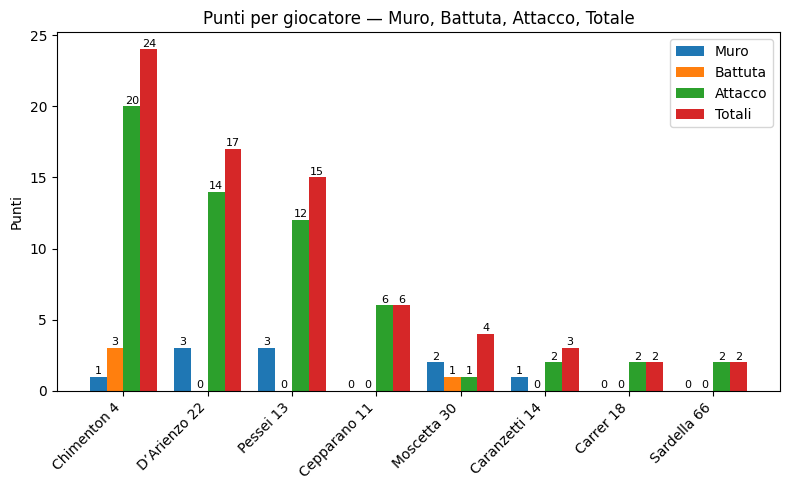

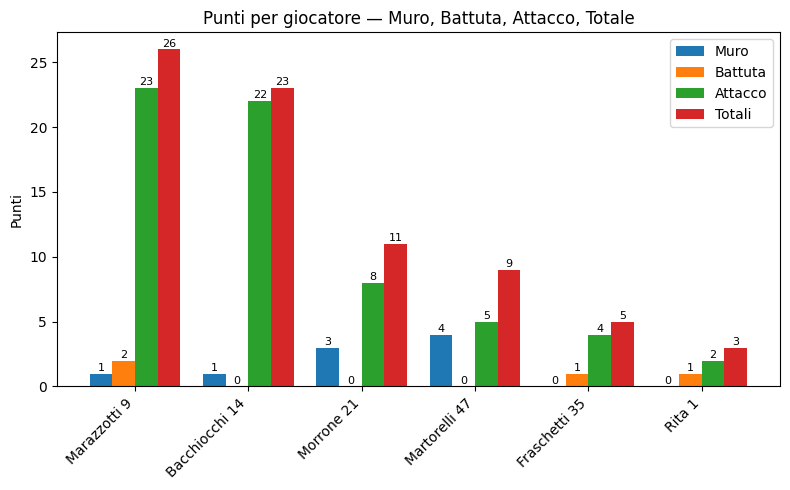

In [38]:
# Build the summary table from the existing `df` and plot
if compare_both_teams:
  pts1 = compute_points_table(df1, prefer_surname=False)
  pts2 = compute_points_table(df2, prefer_surname=False)
  ax1 = plot_points_grouped(pts1, file_path1, sq1, title="Punti per giocatore — Muro, Battuta, Attacco, Totale")
  ax2 = plot_points_grouped(pts2, file_path2, sq2, title="Punti per giocatore — Muro, Battuta, Attacco, Totale")
  display(pts1.reset_index())
  display(pts2.reset_index())
else:
  pts = compute_points_table(df, prefer_surname=False)  # assumes df has columns "Tipo" and "Voto"
  ax = plot_points_grouped(pts, file_path1, sq1, title="Punti per giocatore — Muro, Battuta, Attacco, Totale")
  display(pts.reset_index())

# Grafico efficienza attacco

In [39]:
def compute_attack_eff_breakdown(df, tipo_col="Tipo", player_col=None,
                                 pos=("#",), neg=("/", "="), rec_vote=None):
    """
    Per-player table con:
      - Eff_Tot%, N_Tot  (tutti gli attacchi)
      - Eff_SO%,  N_SO   (attacchi dopo ricezione)
      - Eff_Ctr%, N_Ctr  (contrattacchi)
    Usa: calcola_efficienza, separate_attacks_counterattacks, _eff_from_calcola.
    """
    # player id
    if player_col is None:
        for cand in ("Giocatore", "Cognome", "Numero"):
            if cand in df.columns:
                player_col = cand
                break
        if player_col is None:
            obj_cols = [c for c in df.columns if getattr(df[c], "dtype", None) == object]
            player_col = obj_cols[0] if obj_cols else df.columns[0]

    # Lavoro su una copia con Tipo lower-case: tutto il resto resta invariato
    d = df.copy()
    d[tipo_col] = d[tipo_col].astype(str).str.strip().str.lower()

    # Split SO / CTR direttamente su d (che è già lowercase)
    if rec_vote is None:
        so_d, ctr_d = separate_attacks_counterattacks(d)
    else:
        so_d, ctr_d = separate_attacks_counterattacks(d, rec_vote=list(rec_vote))

    # Tieni solo ATTACCO in minuscolo
    att_all = d.loc[d[tipo_col] == "attacco"]
    so_d    = so_d.loc[so_d[tipo_col] == "attacco"]
    ctr_d   = ctr_d.loc[ctr_d[tipo_col] == "attacco"]

    if att_all.empty and so_d.empty and ctr_d.empty:
        out = pd.DataFrame(columns=["Eff_Tot%", "N_Tot", "Eff_SO%", "N_SO", "Eff_Ctr%", "N_Ctr"])
        out.index.name = "Giocatore"
        return out

    recs = {}

    # Totale
    for player, g in att_all.groupby(att_all[player_col].astype(str).str.strip(), sort=False):
        recs[player] = {
            "N_Tot": int(len(g)),
            "Eff_Tot%": round(_eff_from_calcola(g, "attacco", pos, neg), 1)
        }

    # Dopo ricezione / Contrattacco
    for part_df, n_key, e_key in ((so_d, "N_SO", "Eff_SO%"), (ctr_d, "N_Ctr", "Eff_Ctr%")):
        for player, g in part_df.groupby(part_df[player_col].astype(str).str.strip(), sort=False):
            if player not in recs:
                recs[player] = {"N_Tot": 0, "Eff_Tot%": np.nan}
            recs[player][n_key] = int(len(g))
            recs[player][e_key] = round(_eff_from_calcola(g, "attacco", pos, neg), 1)

    rows = []
    for p, dct in recs.items():
        rows.append({
            "Giocatore": p,
            "Eff_Tot%": dct.get("Eff_Tot%", np.nan), "N_Tot": dct.get("N_Tot", 0),
            "Eff_SO%":  dct.get("Eff_SO%",  np.nan), "N_SO":  dct.get("N_SO",  0),
            "Eff_Ctr%": dct.get("Eff_Ctr%", np.nan), "N_Ctr": dct.get("N_Ctr", 0),
        })

    tbl = (pd.DataFrame(rows)
           .set_index("Giocatore")
           .sort_values(["Eff_Tot%", "N_Tot"], ascending=[False, False]))
    return tbl

def plot_attack_eff_breakdown_bars(
    tbl,
    sq=sq1,
    title="Efficienza attacco — Totale • Dopo ricezione • Contrattacco",
    rotate_labels=45,
    bar_width=0.36,
    gap=0.01,
    min_attacks=3,
    zero_eps=1e-9,
    group_gap=.50  # <-- nuovo: 0 = gruppi contigui; 0.5 = +50% di spazio tra gruppi
):
    """
    Mostra solo i giocatori con N_Tot >= min_attacks.
    Tre barre per giocatore: Totale, Dopo ricezione, Contrattacco.
    Etichette:
      - se eff != 0:   percentuale FUORI + "(n)" DENTRO
      - se eff == 0:   percentuale FUORI e SOTTO di essa "(n)"
    Ordinamento per N_Tot decrescente.
    `group_gap` aumenta lo spazio ORIZZONTALE tra i gruppi (giocatori).
    """
    if tbl.empty:
        raise ValueError("Tabella vuota: nessun attacco rilevato.")

    # Filtra e ordina
    tbl = tbl[tbl["N_Tot"] >= min_attacks]
    if tbl.empty:
        raise ValueError(f"Nessun giocatore con almeno {min_attacks} attacchi totali.")
    tbl = tbl.sort_values("N_Tot", ascending=False)

    players = tbl.index.tolist()
    eff_tot, n_tot = tbl["Eff_Tot%"].to_numpy(), tbl["N_Tot"].to_numpy()
    eff_so,  n_so  = tbl["Eff_SO%"].to_numpy(),  tbl["N_SO"].to_numpy()
    eff_ctr, n_ctr = tbl["Eff_Ctr%"].to_numpy(), tbl["N_Ctr"].to_numpy()

    # NaN -> 0 per il plotting
    eff_tot = np.nan_to_num(eff_tot, nan=0.0)
    eff_so  = np.nan_to_num(eff_so,  nan=0.0)
    eff_ctr = np.nan_to_num(eff_ctr, nan=0.0)

    # Posizioni dei gruppi con gap extra
    gg = max(0.0, float(group_gap))
    x = np.arange(len(players), dtype=float) * (1.0 + gg)

    # Figura più larga se aumenta il gap tra gruppi
    fig_w = max(10, len(players) * (1.0 + gg))
    fig = plt.figure(figsize=(fig_w, 5))
    ax = plt.subplot(111)

    sep = bar_width + gap
    bars_tot = ax.bar(x - sep, eff_tot, width=bar_width, label="Totale")
    bars_so  = ax.bar(x,       eff_so,  width=bar_width, label="Dopo ricezione")
    bars_ctr = ax.bar(x + sep, eff_ctr, width=bar_width, label="Contrattacco")

    ax.set_title(f"[{sq}] "+title)
    #ax.set_xlabel("Giocatori")
    ax.set_ylabel("Efficienza attacco (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(players, rotation=rotate_labels, ha="right")
    ax.legend()

    # ---- Limiti Y dinamici per NON tagliare le etichette ----
    eff_max = float(max(eff_tot.max(), eff_so.max(), eff_ctr.max()))
    eff_min = float(min(eff_tot.min(), eff_so.min(), eff_ctr.min()))
    rng = max(1.0, eff_max - eff_min)
    extra_margin = max(6.0, 0.12 * rng)
    y_min = min(0.0, eff_min) - extra_margin
    y_max = max(0.0, eff_max) + extra_margin
    ax.set_ylim(y_min, y_max)
    pad = max(2.0, 0.035 * (y_max - y_min))  # spazio verticale per la percentuale fuori

    def _inside_text_color(bar):
        r, g, b_col, a = bar.get_facecolor()
        lum = 0.2126*r + 0.7152*g + 0.0722*b_col
        return "black" if lum > 0.6 else "white"

    def _annotate(container, eff_arr, n_arr):
        for i, b in enumerate(container):
            eff = float(eff_arr[i])
            n   = int(n_arr[i])
            xc  = b.get_x() + b.get_width()/2.0

            # Percentuale FUORI (sopra se >=0, sotto se <0)
            is_pos = eff >= 0
            y_out = eff + (pad if is_pos else -pad)
            va_out = "bottom" if is_pos else "top"

            if abs(eff) < zero_eps:
                # Caso 0%: percentuale + riga sotto con (n)
                ax.text(xc, y_out, f"{int(round(eff))}%", ha="center", va=va_out, fontsize=9)
                line_gap = max(1.5, 0.025 * (y_max - y_min))
                ax.text(xc, y_out - line_gap, f"({n})", ha="center", va="top", fontsize=9)
            else:
                # Caso ≠ 0%: percentuale FUORI + (n) DENTRO la barra
                ax.text(xc, y_out, f"{int(round(eff))}%", ha="center", va=va_out, fontsize=9)
                y_in = eff / 2.0
                ax.text(xc, y_in, f"({n})", ha="center", va="center", fontsize=9, color=_inside_text_color(b))

    _annotate(bars_tot, eff_tot, n_tot)
    _annotate(bars_so,  eff_so,  n_so)
    _annotate(bars_ctr, eff_ctr, n_ctr)

    plt.tight_layout()
    save_path = "/".join(file_path1.split('/')[:-1])
    if write_files:
      ax.figure.savefig(save_path + f"/[{sq}] eff_attacco_giocatori.png", dpi=300, bbox_inches="tight", pad_inches=0.1, facecolor="white")
    return ax

def create_attack_eff_plots(df, sq=""):
  eff_tbl = compute_attack_eff_breakdown(
      df,
      pos=("#",),          # positive votes
      neg=("/", "="),      # negative votes
      # rec_vote=["#","+","!","-"]  # ← opzionale: scommenta se vuoi forzare i criteri per separate_attacks_counterattacks
      )
  _ = plot_attack_eff_breakdown_bars(
      eff_tbl,
      sq=sq,
      title="Efficienza attacco — Totale • Dopo ricezione • Contrattacco",
      bar_width=0.3       # barre strette come richiesto
      )

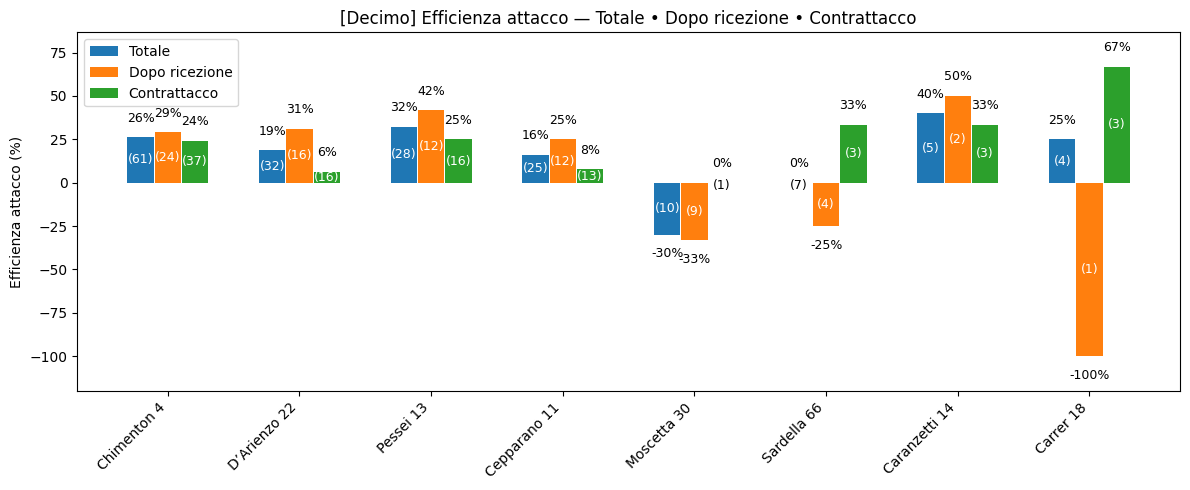

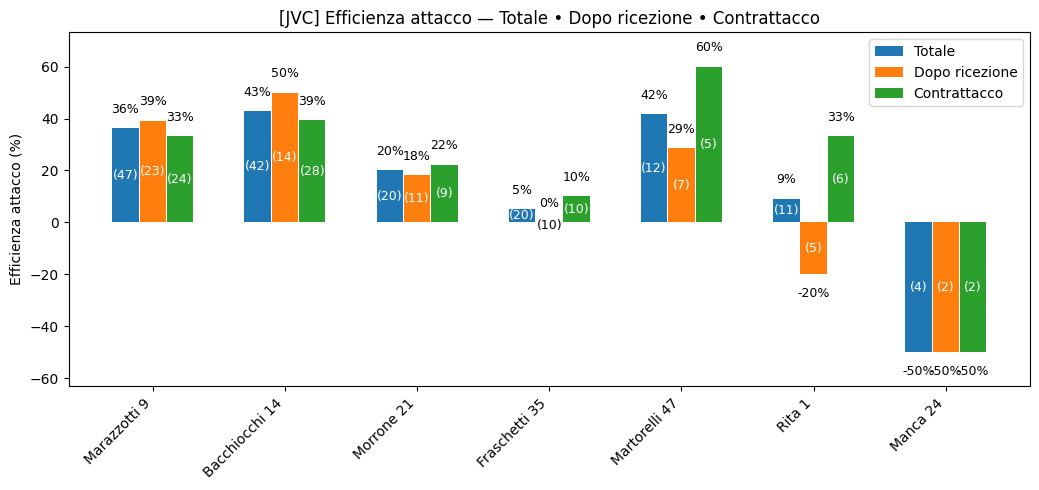

In [40]:
# Attack efficiencies: Total • After reception • Counterattack
if compare_both_teams:
  create_attack_eff_plots(df1, sq=sq1)
  create_attack_eff_plots(df2, sq=sq2)
else:
  create_attack_eff_plots(df, sq=sq1)

# trend per set

In [41]:
# ===== 1) Calcolo metriche per set =====
def compute_set_metrics(
    df,
    set_col="Numero Set",
    tipo_col="Tipo",
    voto_col="Voto",
    # convenzioni di default (adattabili)
    pos_srv=srv_pos,           neg_srv=srv_neg,
    pos_rec=("#", "+"),        neg_rec=("/", "="),
    pos_att=("#"),             neg_att=("/", "="),
    pos_blk=("#", "+"),        neg_blk=("/", "="),
    rec_vote=["#","+","!","-"]              # passa es. ["#","+","!","-"] se vuoi forzare i voti di ricez. “utili”
):
    """
    Ritorna un DataFrame indicizzato per Numero Set con colonne:
      ['Battuta%', 'Ricezione%', 'Attacco SO%', 'Contrattacco%', 'Muro%', 'Errori']
    - Le efficienze sono calcolate con calcola_efficienza(..., total_efficiency=True) su una
      COPIA con `Tipo` in minuscolo (tipo='battuta'/'ricezione'/'attacco'/'muro').
    - 'Attacco SO%' usa il subset 'attacchi dopo ricezione'; 'Contrattacco%' l’altro subset.
    - 'Errori' = conteggio di Voto '=' per Tipo in {'battuta','attacco','alzata'} nel set.
    """
    if set_col not in df.columns:
        raise ValueError(f"Colonna set '{set_col}' non trovata nel DataFrame.")

    out_rows = []
    # iteriamo sui set nell'ordine naturale crescente
    for s in sorted(df[set_col].dropna().unique()):
        d = df[df[set_col] == s].copy()
        if d.empty:
            continue

        # normalizza solo per la logica di filtro (non tocchiamo df originale)
        d[tipo_col] = d[tipo_col].astype(str).str.strip().str.lower()

        def _eff_or_nan(sub_df, tipo, pos, neg):
            sub = sub_df[sub_df[tipo_col] == tipo]
            if sub.empty:
                return float("nan")
            return _eff_scalar(calcola_efficienza(sub, tipo=tipo, pos=list(pos), neg=list(neg), total_efficiency=True))

        # Efficienze per fondamentale
        battuta_pct = _eff_or_nan(d, "battuta",  pos_srv, neg_srv)
        ricez_pct   = _eff_or_nan(d, "ricezione",pos_rec, neg_rec)
        muro_pct    = _eff_or_nan(d, "muro",     pos_blk, neg_blk)

        # Split attacchi dopo ricezione / contrattacco
        so_d, ctr_d = separate_attacks_counterattacks(d) if rec_vote is None \
                      else separate_attacks_counterattacks(d, rec_vote=list(rec_vote))
        so_d  = so_d [so_d [tipo_col] == "attacco"]
        ctr_d = ctr_d[ctr_d[tipo_col] == "attacco"]

        att_so_pct  = _eff_scalar(calcola_efficienza(so_d,  tipo="attacco", pos=list(pos_att), neg=list(neg_att), total_efficiency=True)) if not so_d.empty  else float("nan")
        att_ctr_pct = _eff_scalar(calcola_efficienza(ctr_d, tipo="attacco", pos=list(pos_att), neg=list(neg_att), total_efficiency=True)) if not ctr_d.empty else float("nan")

        # Errori totali (battuta, attacco, alzata) nel set
        err_mask = (d[voto_col].astype(str).str.strip() == "=") & (d[tipo_col].isin(["battuta","attacco","alzata"]))
        errors = int(err_mask.sum())

        out_rows.append({
            set_col: s,
            "Battuta%": battuta_pct,
            "Ricezione%": ricez_pct,
            "Attacco SO%": att_so_pct,
            "Contrattacco%": att_ctr_pct,
            "Muro%": muro_pct,
            "Errori": errors
        })

    tbl = (pd.DataFrame(out_rows).set_index(set_col)
           .sort_index())
    return tbl

def _align_zero_two_axes(ax, ax2, right_data_max, pad_ratio=0.25, allow_negative_right=True):
    """
    Allinea la posizione dello zero dei due assi y (ax a sinistra, ax2 a destra).
    - right_data_max: massimo dato 'naturale' dell'asse destro (es. max errori)
    - pad_ratio: padding percentuale sopra (es. 0.25 = +25%)
    - allow_negative_right: se True consente min y2 < 0 per allineare esattamente lo zero;
                            se False, forza y2_min=0 e porta lo zero in basso su ax.
    """
    y_min, y_max = ax.get_ylim()
    if y_max <= y_min + 1e-9:
        return  # range degenerato, niente da fare

    # frazione (0 in [y_min, y_max])
    frac = (0.0 - y_min) / (y_max - y_min)

    # top dell'asse destro con un po' di aria
    y2_top = float(right_data_max) * (1.0 + pad_ratio)
    if y2_top <= 0:
        y2_top = 1.0  # fallback

    if allow_negative_right:
        # scegli y2_min così che 0 cada alla stessa frazione
        # frac = (0 - y2_min) / (y2_top - y2_min)  ->  y2_min = -frac * y2_top / (1 - frac)
        denom = max(1e-9, (1.0 - frac))
        y2_min = -frac * y2_top / denom
    else:
        # niente valori negativi sull'asse destro: y2_min = 0
        y2_min = 0.0
        # per coerenza porta lo zero in basso anche a sinistra
        if y_min < 0:
            ax.set_ylim(0.0, y_max)
            y_min, y_max = ax.get_ylim()
            frac = 0.0  # ora zero è in basso

    ax2.set_ylim(y2_min, y2_top)

    # linea dello zero (aiuta a verificare l'allineamento)
    ax.axhline(0, color="0.5", lw=1, alpha=0.6)


# ===== 2) Grafico a barre per set (5 efficienze su asse sinistro + Errori su asse destro) =====
def plot_set_efficiency_groups(
    tbl,
    sq=sq1,
    title="Efficienze per Set (+ Errori)",
    rotate_labels=0,
    bar_width=0.22,
    intra_gap=0.06,
    group_gap=1.2,
    force_sets=True,
    num_sets=5,
    annotate=True,
    include_total_group=True,
    # --- per costruire il gruppo "Tot" ---
    df_all=None,
    set_col="Numero Set",
    tipo_col="Tipo",
    voto_col="Voto",
    rec_vote=None,
    pos_srv=srv_pos,            neg_srv=srv_neg,
    pos_rec=("#", "+"),         neg_rec=("/", "="),
    pos_att=("#",),             neg_att=("/", "="),
    pos_blk=("#", "+"),         neg_blk=("/", "="),
    # --- riquadro rosso intorno al gruppo Tot ---
    highlight_total_group=True,
    highlight_color="red",
    highlight_pad=0.06,  # frazione: 0.06 = 6% di padding lato e top/bottom
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    def _align_zero_two_axes(ax, ax2, right_data_max, pad_ratio=0.25, allow_negative_right=True):
        y_min, y_max = ax.get_ylim()
        if y_max <= y_min + 1e-9:
            return
        frac = (0.0 - y_min) / (y_max - y_min)
        y2_top = float(right_data_max) * (1.0 + pad_ratio) if right_data_max > 0 else 1.0
        if allow_negative_right:
            denom = max(1e-9, (1.0 - frac))
            y2_min = -frac * y2_top / denom
        else:
            y2_min = 0.0
            if y_min < 0:
                ax.set_ylim(0.0, y_max)
        ax2.set_ylim(y2_min, y2_top)
        ax.axhline(0, color="0.5", lw=1, alpha=0.6)

    def _eff_or_nan(sub_df, tipo, pos, neg):
        ss = sub_df[sub_df[tipo_col] == tipo]
        if ss.empty:
            return float("nan")
        return _eff_scalar(calcola_efficienza(ss, tipo=tipo, pos=list(pos), neg=list(neg), total_efficiency=True))

    if tbl.empty:
        raise ValueError("Tabella vuota: nessun set disponibile.")

    metrics_pct = ["Battuta%", "Ricezione%", "Attacco SO%", "Contrattacco%", "Muro%"]
    metric_errs = "Errori"
    missing = [c for c in metrics_pct + [metric_errs] if c not in tbl.columns]
    if missing:
        raise ValueError(f"Mancano colonne in tbl: {missing}")

    # Forza set 1..num_sets e marca quelli reali
    tbl_pad = tbl.copy()
    try:
        tbl_pad.index = pd.to_numeric(tbl_pad.index, errors="coerce")
    except Exception:
        pass

    if force_sets:
        desired_sets = list(range(1, num_sets + 1))
        existing = set(tbl_pad.index.tolist())
        tbl_pad = tbl_pad.reindex(desired_sets)
        annot_mask = [s in existing for s in desired_sets]
    else:
        desired_sets = list(tbl_pad.index)
        annot_mask = [True] * len(desired_sets)

    plot_pct = tbl_pad[metrics_pct].copy().fillna(0.0)
    plot_err = tbl_pad[metric_errs].copy().fillna(0.0)
    labels = list(desired_sets)

    # Gruppo Tot
    if include_total_group:
        if df_all is None:
            raise ValueError("Per aggiungere il gruppo 'Tot' serve df_all (dati grezzi).")
        real_sets = [s for s, ex in zip(desired_sets, annot_mask) if ex]
        df_sub = df_all[df_all[set_col].isin(real_sets)].copy()
        df_sub[tipo_col] = df_sub[tipo_col].astype(str).str.strip().str.lower()

        so_d, ctr_d = separate_attacks_counterattacks(df_sub) if rec_vote is None \
                      else separate_attacks_counterattacks(df_sub, rec_vote=list(rec_vote))
        so_d  = so_d [so_d [tipo_col] == "attacco"]
        ctr_d = ctr_d[ctr_d[tipo_col] == "attacco"]

        totals = {
            "Battuta%":      _eff_or_nan(df_sub, "battuta",  pos_srv, neg_srv),
            "Ricezione%":    _eff_or_nan(df_sub, "ricezione",pos_rec, neg_rec),
            "Attacco SO%":   (_eff_scalar(calcola_efficienza(so_d,  tipo="attacco", pos=list(pos_att), neg=list(neg_att), total_efficiency=True)) if not so_d.empty else float("nan")),
            "Contrattacco%": (_eff_scalar(calcola_efficienza(ctr_d, tipo="attacco", pos=list(pos_att), neg=list(neg_att), total_efficiency=True)) if not ctr_d.empty else float("nan")),
            "Muro%":         _eff_or_nan(df_sub, "muro",     pos_blk, neg_blk),
        }
        err_mask = (df_sub[voto_col].astype(str).str.strip() == "=") & (df_sub[tipo_col].isin(["battuta","attacco","alzata"]))
        tot_err = int(err_mask.sum())

        plot_pct.loc["Tot"] = [totals[k] if np.isfinite(totals[k]) else 0.0 for k in metrics_pct]
        plot_err.loc["Tot"] = tot_err
        labels.append("Tot")
        annot_mask.append(True)

    # Posizioni X
    n_groups = len(labels)
    x = np.arange(n_groups, dtype=float) * (1.0 + group_gap)
    m = len(metrics_pct) + 1
    offsets = [(i - (m - 1) / 2) * (bar_width + intra_gap) for i in range(m)]

    fig = plt.figure(figsize=(max(10, n_groups * (1.2 + group_gap)), 5))
    ax = plt.subplot(111)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(6)]

    # Barre % (asse sinistro)
    containers_pct = []
    for i, col in enumerate(metrics_pct):
        cont = ax.bar(x + offsets[i], plot_pct[col].to_numpy(), width=bar_width, label=col, color=colors[i])
        containers_pct.append(cont)

    # Limiti Y sinistra
    eff_vals = plot_pct.to_numpy().ravel()
    eff_max = float(np.nanmax(eff_vals)) if eff_vals.size else 0.0
    eff_min = float(np.nanmin(eff_vals)) if eff_vals.size else 0.0
    rng = max(1.0, eff_max - eff_min)
    extra = max(6.0, 0.12 * rng)
    y_min = min(0.0, eff_min) - extra
    y_max = max(0.0, eff_max) + extra
    ax.set_ylim(y_min, y_max)

    # Errori (asse destro) + allineamento zero
    ax2 = ax.twinx()
    cont_err = ax2.bar(x + offsets[-1], plot_err.to_numpy(), width=bar_width, label="Errori", color=colors[5])
    err_max = float(plot_err.max()) if len(plot_err) else 1.0
    _align_zero_two_axes(ax, ax2, right_data_max=err_max, pad_ratio=0.25, allow_negative_right=True)

    # === Riquadro rosso che incornicia il gruppo "Tot" ===
    if include_total_group and highlight_total_group:
        last = n_groups - 1
        # estensione orizzontale del gruppo Tot (barre di % e barre "Errori")
        group_left  = min(x[last] + off - bar_width/2 for off in offsets)
        group_right = max(x[last] + off + bar_width/2 for off in offsets)
        # padding orizzontale
        pad_lr = highlight_pad * (group_right - group_left)
        group_left  -= pad_lr
        group_right += pad_lr
        # estensione verticale (usa l'intero range dell'asse sinistro con un po' di padding)
        y0, y1 = ax.get_ylim()
        pad_tb = highlight_pad * (y1 - y0)
        y0 += pad_tb
        y1 -= pad_tb
        rect = Rectangle((group_left, y0), group_right - group_left, y1 - y0,
                         fill=False, ec=highlight_color, lw=2.2, zorder=6, clip_on=False)
        ax.add_patch(rect)

    # Assi / legenda
    ax.set_title(f"[{sq}] "+title)
    ax.set_xlabel("Numero Set")
    ax.set_ylabel("Efficienza (%)")
    ax2.set_ylabel("Errori (conteggio)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate_labels, ha="center")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best", ncol=3)

    # Annotazioni (solo set reali + Tot)
    if annotate:
        pad_pct = max(2.0, 0.035 * (y_max - y_min))
        for i, col in enumerate(metrics_pct):
            vals = plot_pct[col].to_numpy()
            for j, b in enumerate(containers_pct[i]):
                if j >= len(annot_mask) or not annot_mask[j]:
                    continue
                v = float(vals[j])
                y_out = v + (pad_pct if v >= 0 else -pad_pct)
                va = "bottom" if v >= 0 else "top"
                ax.text(b.get_x() + b.get_width()/2, y_out, f"{int(round(v))}%", ha="center", va=va, fontsize=9)

        y2_min, y2_max = ax2.get_ylim()
        pad_err = max(0.5, 0.03 * (y2_max - y2_min))
        for j, b in enumerate(cont_err):
            if j >= len(annot_mask) or not annot_mask[j]:
                continue
            v = int(plot_err.iloc[j])
            ax2.text(b.get_x() + b.get_width()/2, b.get_height() + pad_err, str(v), ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    save_path = "/".join(file_path1.split('/')[:-1])

    fig = ax.get_figure()
    if write_files:
      fig.savefig(save_path + f"/[{sq}] bar_eff_per_set.png", dpi=300, bbox_inches="tight", pad_inches=0.1, facecolor="white")
    return ax, ax2

def create_metrics_plot(df, sq=""):
  tbl_set = compute_set_metrics(df)
  _ = plot_set_efficiency_groups(
      tbl_set,
      sq=sq,
      df_all=df,                 # per calcolare il gruppo "Tot"
      include_total_group=True,  # gruppo totale attivo
      highlight_total_group=True # riquadro rosso intorno al gruppo Tot
      )

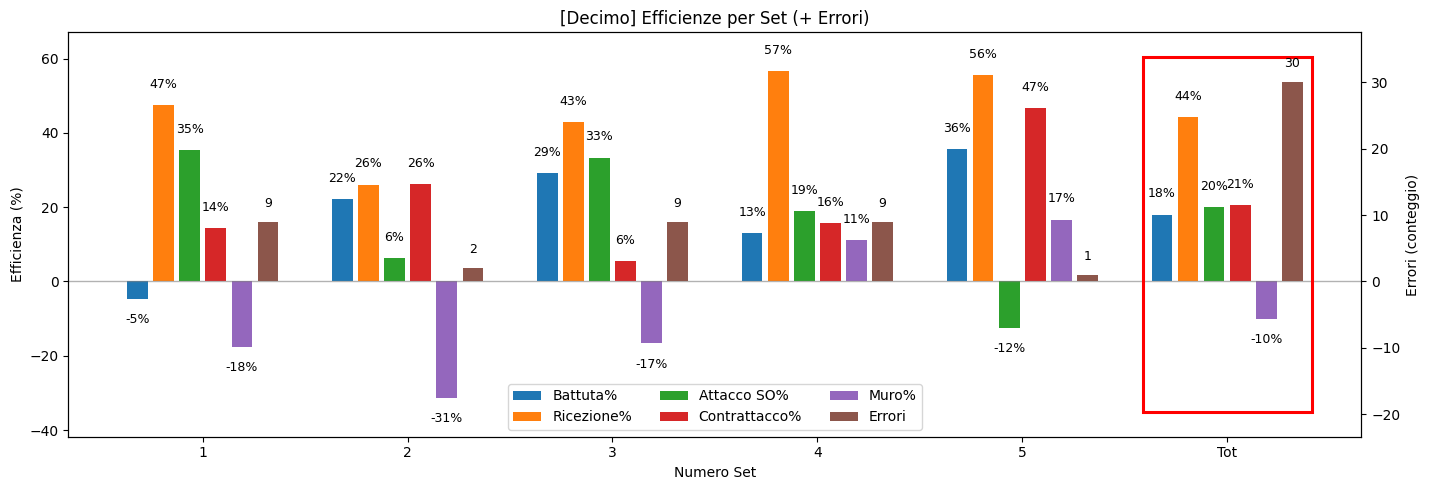

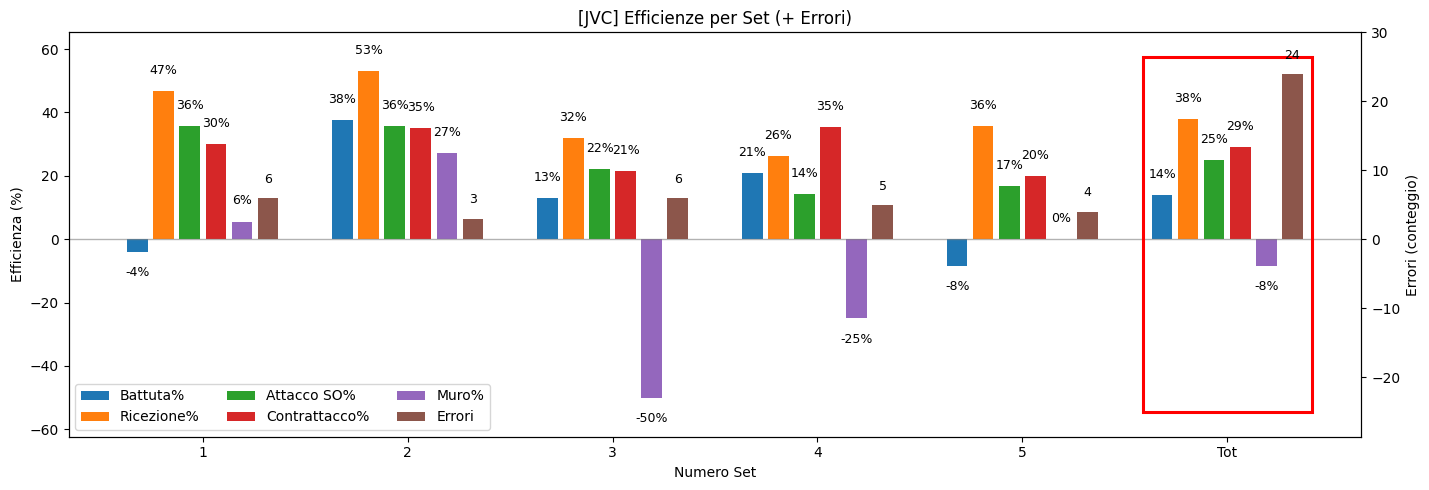

In [42]:
if compare_both_teams:
  create_metrics_plot(df1, sq=sq1)
  create_metrics_plot(df2, sq=sq2)
else:
  create_metrics_plot(df, sq=sq1)


# radar

In [43]:
def plot_set_radar(
    df_raw,
    #tbl,
    df_raw_b=None,         # opzionale: secondo raw dataframe
    tbl_b=None,            # opzionale: seconda tabella (se None, riusa `tbl`)
    sets=None,
    title="Radar per Set — Battuta / Ricezione / Attacco SO / Contrattacco / Muro",
    metrics=None,
    rmin=None, rmax=None,
    annotate=True,
    start_with_green=True,
    label_offset=0.08,
    show_errors="legend",  # "legend" | "annotate" | "spoke"
    errors_col="Errori",
    error_spoke_label="Errori (norm.)",
    errors_panel_side="right",
    errors_panel_pad=0.08,
    labels=("Aggregato A", "Aggregato B"),
    colors=None
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    tbl = compute_set_metrics(df_raw)
    if df_raw_b is not None:
        tbl_b = compute_set_metrics(df_raw_b)

    # --- check input base ---
    if tbl is None or getattr(tbl, "empty", True):
        raise ValueError("`tbl` è vuoto: nessun set disponibile per il primo dataset.")
    if df_raw is None or len(df_raw) == 0:
        raise ValueError("`df_raw` è richiesto e deve contenere 'Numero Set','Tipo','Voto'.")
    if df_raw_b is not None and tbl_b is None:
        tbl_b = tbl

    if metrics is None:
        metrics = ["Battuta%", "Ricezione%", "Attacco SO%", "Contrattacco%", "Muro%"]

    # --- colonne disponibili (case-insensitive) su tbl A ---
    cols_lower_map = {str(c).strip().lower(): c for c in tbl.columns}
    sel_cols = []
    for m in metrics:
        key = str(m).strip().lower()
        if key not in cols_lower_map:
            raise ValueError(f"Colonna '{m}' non trovata in `tbl`. Disponibili: {list(tbl.columns)}")
        sel_cols.append(cols_lower_map[key])
    if errors_col not in tbl.columns:
        raise ValueError(f"Colonna errori '{errors_col}' non trovata in `tbl`.")

    # --- helper: estrai scalare float robusto ---
    def _to_float_scalar(x, context=""):
        import numpy as _np
        import pandas as _pd

        try:
            return float(x)
        except Exception:
            pass

        if isinstance(x, (_pd.Series, _pd.Index)):
            xx = _pd.to_numeric(x, errors="coerce").dropna()
            if len(xx) > 0:
                return float(xx.iloc[0])

        if isinstance(x, _pd.DataFrame):
            xx = _pd.to_numeric(x.stack(), errors="coerce").dropna()
            if len(xx) > 0:
                return float(xx.iloc[0])

        if isinstance(x, dict):
            for v in x.values():
                try:
                    return float(v)
                except Exception:
                    continue

        try:
            flat = _np.ravel(_np.asarray(x, dtype=object))
            for v in flat:
                try:
                    return float(v)
                except Exception:
                    continue
        except Exception:
            pass

        raise ValueError(f"Valore non numerico per {context}: tipo={type(x).__name__}, repr={repr(x)[:120]}")

    # --- helper: porta in percentuale se necessario ---
    def _to_percent(val):
        try:
            v = float(val)
        except Exception:
            return val
        # se il valore è verosimilmente fra -1 e 1, interpretalo come frazione -> percento
        if np.isfinite(v) and abs(v) <= 1.0:
            return v * 100.0
        return v

    # --- wrapper efficienza coerente con i segni ---
    set_col, tipo_col, voto_col = "Numero Set", "Tipo", "Voto"

    def _eff_or_nan(sub_df, tipo, pos, neg, context=""):
        if sub_df.empty:
            return float("nan")
        ss = sub_df[sub_df[tipo_col] == tipo]
        if ss.empty:
            return float("nan")
        val = calcola_efficienza(
            ss, tipo=tipo, pos=list(pos), neg=list(neg), total_efficiency=True
        )
        val = _to_float_scalar(val, context=context)
        return _to_percent(val)

    def _prepare_dataset(_df_raw, _tbl):
        data_tbl = _tbl.copy()
        try:
            data_tbl.index = pd.to_numeric(data_tbl.index, errors="coerce")
        except Exception:
            pass

        if sets is not None:
            keep = [s for s in sets if s in data_tbl.index]
            if not keep:
                raise ValueError("Nessuno dei set richiesti è presente nella tabella fornita.")
            data_tbl = data_tbl.loc[keep]

        chosen = list(data_tbl.index.astype(int)) if len(data_tbl.index) else []
        if not chosen:
            try:
                chosen = sorted(
                    pd.to_numeric(_df_raw["Numero Set"], errors="coerce").dropna().astype(int).unique().tolist()
                )
            except Exception:
                pass

        d = _df_raw.copy()
        for col in (set_col, tipo_col, voto_col):
            if col not in d.columns:
                raise ValueError("Il df grezzo deve contenere le colonne 'Numero Set','Tipo','Voto'.")
        d[set_col] = pd.to_numeric(d[set_col], errors="coerce")
        if chosen:
            d = d[d[set_col].isin(chosen)]
        d[tipo_col] = d[tipo_col].astype(str).str.strip().str.lower()
        d[voto_col] = d[voto_col].astype(str).str.strip()
        return d, chosen

    # segni (attenzione alle tuple a 1 elemento: serve la virgola)
    pos_srv, neg_srv = srv_pos, srv_neg
    pos_rec, neg_rec = ("#", "+"), ("/", "=")
    pos_att, neg_att = ("#",), ("/", "=")
    pos_blk, neg_blk = ("#", "+"), ("/", "=")

    def _aggregate(_df_raw, _tbl, ds_name="A"):
        d, chosen_sets = _prepare_dataset(_df_raw, _tbl)

        # split SO / Contrattacco
        try:
            so_d, ctr_d = separate_attacks_counterattacks(d)
        except TypeError:
            so_d, ctr_d = separate_attacks_counterattacks(d, rec_vote=None)

        # normalizza anche qui il campo Tipo (può arrivare con maiuscole)
        if so_d is None:
            import pandas as pd
            so_d = pd.DataFrame(columns=d.columns)
        if ctr_d is None:
            import pandas as pd
            ctr_d = pd.DataFrame(columns=d.columns)
        if len(so_d) > 0 and "Tipo" in so_d.columns:
            so_d["Tipo"] = so_d["Tipo"].astype(str).str.strip().str.lower()
        if len(ctr_d) > 0 and "Tipo" in ctr_d.columns:
            ctr_d["Tipo"] = ctr_d["Tipo"].astype(str).str.strip().str.lower()

        so_d  = so_d [so_d ["Tipo"] == "attacco"] if len(so_d)  else so_d
        ctr_d = ctr_d[ctr_d["Tipo"] == "attacco"] if len(ctr_d) else ctr_d

        vals_map = {
            "Battuta%":      _eff_or_nan(d,    "battuta",   pos_srv, neg_srv, context=f"{ds_name}: Battuta%"),
            "Ricezione%":    _eff_or_nan(d,    "ricezione", pos_rec, neg_rec, context=f"{ds_name}: Ricezione%"),
            "Attacco SO%":   (_to_percent(_to_float_scalar(
                                    calcola_efficienza(so_d,  tipo="attacco", pos=list(pos_att), neg=list(neg_att), total_efficiency=True)
                               , context=f"{ds_name}: Attacco SO%")) if not so_d.empty else float("nan")),
            "Contrattacco%": (_to_percent(_to_float_scalar(
                                    calcola_efficienza(ctr_d, tipo="attacco", pos=list(pos_att), neg=list(neg_att), total_efficiency=True)
                               , context=f"{ds_name}: Contrattacco%")) if not ctr_d.empty else float("nan")),
            "Muro%":         _eff_or_nan(d,    "muro",      pos_blk, neg_blk, context=f"{ds_name}: Muro%"),
        }

        vals = np.array([vals_map.get(m, np.nan) for m in metrics], dtype=float)
        vals = np.nan_to_num(vals, nan=0.0)

        err_mask = (d[voto_col] == "=") & (d[tipo_col].isin(["battuta","attacco","alzata"]))
        err_total = int(err_mask.sum())
        return vals, err_total, chosen_sets

    # --- aggregazioni ---
    vals_a, err_a, sets_a = _aggregate(df_raw, tbl, ds_name="A")
    has_b = (df_raw_b is not None)
    if has_b:
        vals_b, err_b, sets_b = _aggregate(df_raw_b, tbl_b, ds_name="B")
    else:
        vals_b = err_b = sets_b = None

    # --- angoli & labels ---
    use_spoke = (show_errors == "spoke")
    M = len(metrics) + (1 if use_spoke else 0)
    theta = np.linspace(0, 2*np.pi, M, endpoint=False)
    theta_closed = np.concatenate([theta, theta[:1]])
    labels_ang = list(metrics) + ([error_spoke_label] if use_spoke else [])

    # --- limiti radiali condivisi ---
    def _vals_for_limits(v, err_tot):
        if not use_spoke:
            return v
        e_norm = np.array([100.0 if err_tot > 0 else 0.0], dtype=float)
        return np.concatenate([v, e_norm])

    vals_for_limits = _vals_for_limits(vals_a, err_a)
    if has_b:
        vals_for_limits = np.concatenate([vals_for_limits, _vals_for_limits(vals_b, err_b)])

    finite_vals = vals_for_limits[np.isfinite(vals_for_limits)]
    if finite_vals.size == 0:
        finite_vals = np.array([0.0])
    dmin, dmax = float(np.nanmin(finite_vals)), float(np.nanmax(finite_vals))
    if rmin is None or rmax is None:
        span = max(1.0, dmax - dmin)
        pad  = max(5.0, 0.12 * span)
        if rmin is None: rmin = min(0.0, dmin) - pad
        if rmax is None: rmax = max(0.0, dmax) + pad
        if rmax - rmin < 1e-6:
            rmin, rmax = rmin - 1.0, rmax + 1.0

    # --- colori & label legenda ---
    cmap = plt.get_cmap("tab10")
    if colors is not None:
        color_a, color_b = (colors + (None, None))[:2]
    else:
        color_a = cmap(2) if start_with_green else cmap(0)
        color_b = cmap(3) if start_with_green else cmap(1)

    label_a = labels[0] if labels and len(labels) > 0 else "Aggregato A"
    label_b = labels[1] if labels and len(labels) > 1 else "Aggregato B"

    # --- plot ---
    fig = plt.figure(figsize=(7.8, 6))
    ax = plt.subplot(111, polar=True)
    ax.set_title(title, pad=20)
    ax.set_xticks(theta)
    ax.set_xticklabels(labels_ang)
    ax.set_rlim(rmin, rmax)
    ax.grid(True, linestyle=":")
    if rmin < 0 < rmax:
        ax.plot(np.linspace(0, 2*np.pi, 360), np.zeros(360), linewidth=1.2)

    # Serie A
    vals_plot_a = vals_a.copy()
    if use_spoke:
        e_norm_a = np.array([100.0 if err_a > 0 else 0.0], dtype=float)
        vals_plot_a = np.concatenate([vals_plot_a, e_norm_a])
    vals_closed_a = np.concatenate([vals_plot_a, vals_plot_a[:1]])
    line_a, = ax.plot(theta_closed, vals_closed_a, linewidth=2.0, color=color_a, label=label_a)
    ax.fill(theta_closed, vals_closed_a, alpha=0.15, color=color_a)

    # Serie B (opzionale)
    if has_b:
        vals_plot_b = vals_b.copy()
        if use_spoke:
            e_norm_b = np.array([100.0 if err_b > 0 else 0.0], dtype=float)
            vals_plot_b = np.concatenate([vals_plot_b, e_norm_b])
        vals_closed_b = np.concatenate([vals_plot_b, vals_plot_b[:1]])
        line_b, = ax.plot(theta_closed, vals_closed_b, linewidth=2.0, color=color_b, label=label_b)
        ax.fill(theta_closed, vals_closed_b, alpha=0.15, color=color_b)

    # --- annotazioni ---
    if annotate:
        off = float(label_offset) * (rmax - rmin)
        for t, v in zip(theta[:len(metrics)], vals_a):
            r_text = v + (off if v >= 0 else -off)
            ax.text(t, r_text, f"{int(round(v))}%", ha="center", va="center", fontsize=9, color=color_a)
        if use_spoke:
            t_err = theta[-1]; v_err = vals_plot_a[-1]
            r_text = v_err + (off if v_err >= 0 else -off)
            ax.text(t_err, r_text, f"err {err_a}", ha="center", va="center", fontsize=9, color=color_a)

        if has_b:
            for t, v in zip(theta[:len(metrics)], vals_b):
                r_text = v + (off if v >= 0 else -off)
                ax.text(t, r_text, f"{int(round(v))}%", ha="center", va="center", fontsize=9, color=color_b)
            if use_spoke:
                t_err = theta[-1]; v_err = vals_plot_b[-1]
                r_text = v_err + (off if v_err >= 0 else -off)
                ax.text(t_err, r_text, f"err {err_b}", ha="center", va="center", fontsize=9, color=color_b)

    # --- pannelli laterali (err/set) ---
    x_panel = 1.08 if errors_panel_side == "right" else -0.10
    ha_panel = "left" if errors_panel_side == "right" else "right"
    y0 = 0.92

    sets_str_a = "[" + ",".join(str(int(s)) for s in (sets_a or [])) + "]" if sets_a else "[]"
    ax.text(x_panel, y0, f"err tot {err_a}", transform=ax.transAxes, ha=ha_panel, va="center",
            fontsize=9, color=color_a, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color_a, lw=0.8, alpha=0.9))
    ax.text(x_panel, y0 - errors_panel_pad*1.1, f"Set: {sets_str_a}", transform=ax.transAxes, ha=ha_panel, va="center",
            fontsize=9, color=color_a, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color_a, lw=0.8, alpha=0.9))

    if has_b:
        sets_str_b = "[" + ",".join(str(int(s)) for s in (sets_b or [])) + "]" if sets_b else "[]"
        ax.text(x_panel, y0 - errors_panel_pad*2.2, f"err tot {err_b}", transform=ax.transAxes, ha=ha_panel, va="center",
                fontsize=9, color=color_b, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color_b, lw=0.8, alpha=0.9))
        ax.text(x_panel, y0 - errors_panel_pad*3.3, f"Set: {sets_str_b}", transform=ax.transAxes, ha=ha_panel, va="center",
                fontsize=9, color=color_b, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color_b, lw=0.8, alpha=0.9))

    # --- legenda dataset: SEMPRE visibile e interna ---
    handles = [line_a] + ([line_b] if has_b else [])
    labels_leg = [label_a] + ([label_b] if has_b else [])
    ax.legend(handles, labels_leg, loc="upper left", bbox_to_anchor=(0.02, 0.98))

    plt.tight_layout()

    # salvataggio (compatibilità con tuoi flag globali)
    try:
        if 'write_files' in globals() and write_files:
            save_dir = "/".join(file_path1.split('/')[:-1]) if 'file_path1' in globals() else "."
            ax.figure.savefig(save_dir + f"/radar_tot_eff_{int(sets[0])}.png", dpi=300, bbox_inches="tight", pad_inches=0.1, facecolor="white")
    except Exception:
        pass

    return ax


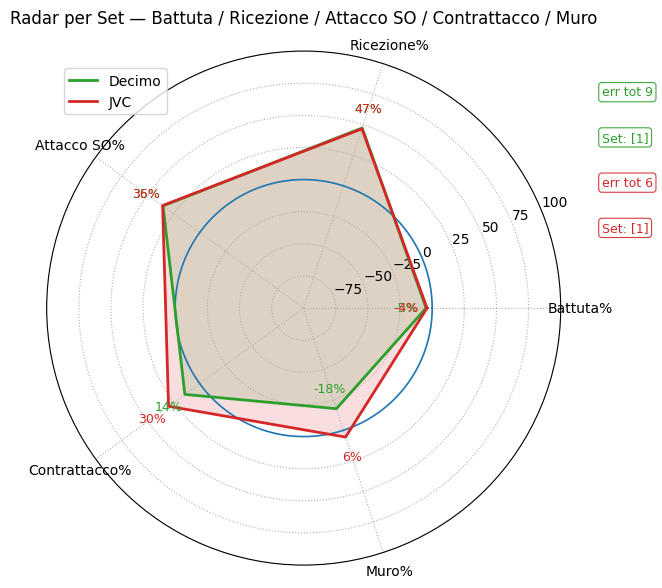

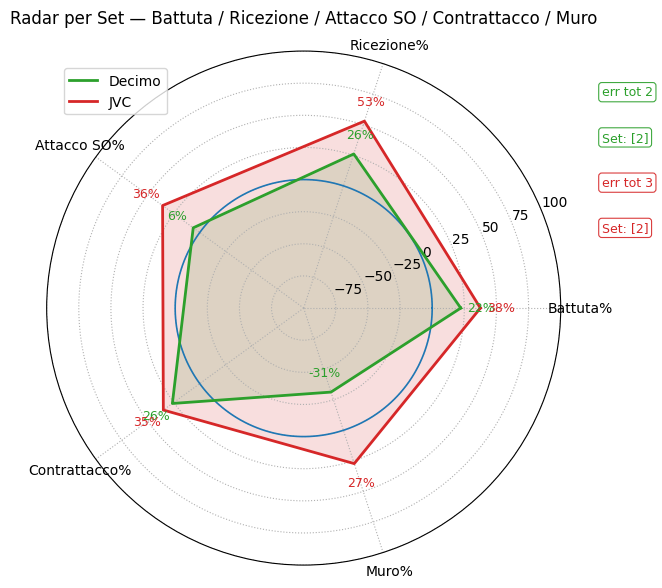

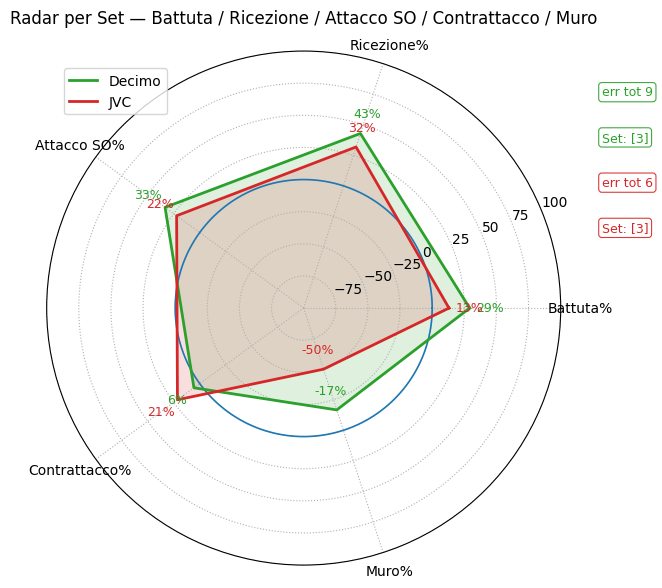

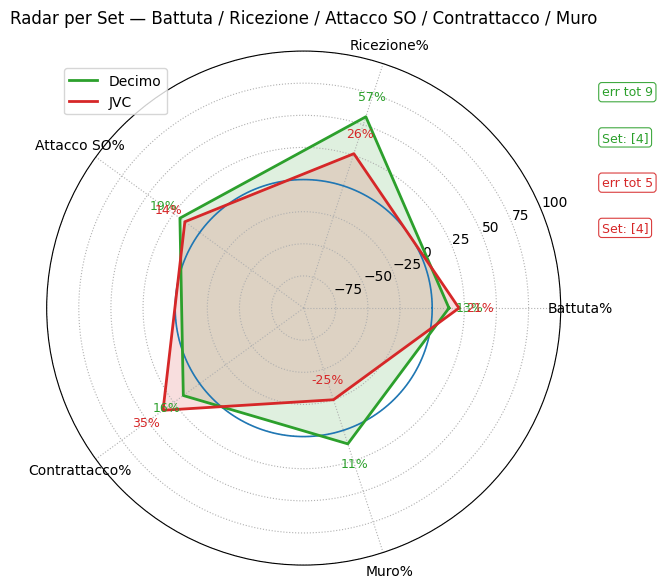

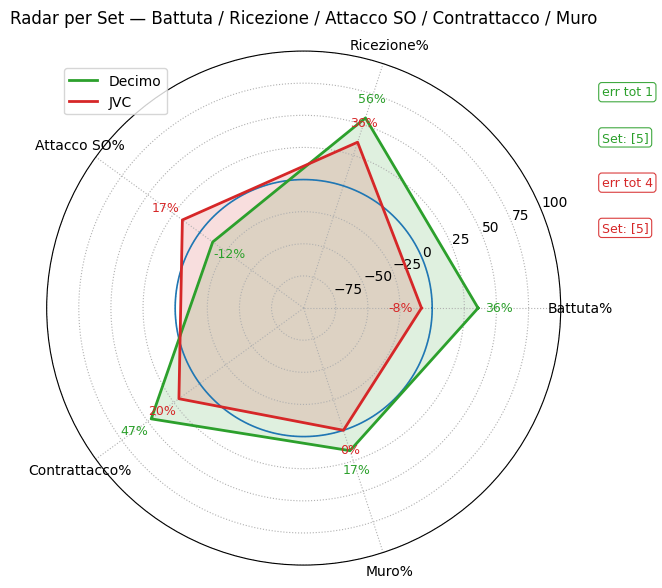

In [44]:
#sets=[4]
all_sets = df1['Numero Set'].unique()
for sets in all_sets:
  sets = [sets]
  if compare_both_teams:
    plot_set_radar(
        df_raw=df1,
        df_raw_b=df2,
        sets=sets,
        labels=(sq1,sq2),
        rmin=-100, rmax=100, show_errors="annotate"
        )
  else:
    plot_set_radar(
        df_raw=df,
        sets=sets,
        labels=(sq1,),
        rmin=-100, rmax=100, show_errors="annotate"
        )


In [45]:
#df2[(df2['Tipo']=='attacco') & (df2['Voto']=='=')].groupby('Numero Set').size()
int(sets[0])

5

# altro

In [31]:
licenziati = pd.DataFrame()
licenziati = pd.concat([licenziati, df2[(df2['Numero Set']==1) & (df2['Punti Locali']<=22) & ((df2['Punti Ospiti']<=15))]])
licenziati = pd.concat([licenziati, df2[(df2['Numero Set']==3) & (df2['Punti Locali']>=11) & ((df2['Punti Ospiti']>=16))]])
licenziati = pd.concat([licenziati, df2[(df2['Numero Set']==4) & (df2['Punti Locali']<=20) & ((df2['Punti Ospiti']<=15))]])

caranzetti = df2[~df2['id'].isin(licenziati['id'].values)]

In [ ]:
caranzetti.id.values

array([ 88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 158, 159, 160, 161, 162, 163, 164, 165, 166,
       167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
       180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192,
       193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205,
       206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,
       219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231,
       232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244,
       245, 246, 247, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258,
       259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 27

In [ ]:
export_tabellino_to_xlsx(
      df=licenziati,
      filepath=str(base) + "/" + filename1.replace('.xlsx', ' [tab Licenziati].xlsx'),
      sheet_name="Tabellino",
      top_start_row=0,      # intestazione in riga 1
      bottom_start_row=15   # blocco basso da riga 16
  )
export_tabellino_to_xlsx(
      df=caranzetti,
      filepath=str(base) + "/" + filename1.replace('.xlsx', ' [tab Caranzetti].xlsx'),
      sheet_name="Tabellino",
      top_start_row=0,      # intestazione in riga 1
      bottom_start_row=15   # blocco basso da riga 16
  )

'/content/drive/MyDrive/Pallavolo/Decimo Roma/2025-2026/Serie D/Match analysis/(a5) Roma7 - Decimo 2-3/[Roma7] Roma7 - decimo [tab Caranzetti].xlsx'

# tabellino

In [ ]:
def _attack_tipo_value(df, tipo_col="Tipo"):
    vals = pd.Series(df[tipo_col].dropna().astype(str).unique())
    cand = vals[vals.str.contains("att", case=False, na=False)]
    exact = cand[cand == "Attacco"]
    return exact.iloc[0] if not exact.empty else (cand.iloc[0] if not cand.empty else "Attacco")

def _eff_scalar(res):
    """Estrae lo scalare dalla tua calcola_efficienza(total_efficiency=True)."""
    if isinstance(res, pd.DataFrame) and "Efficienza Totale" in res.columns:
        v = res["Efficienza Totale"].iloc[0]
    else:
        v = float(res)
    return (v*100) if -1.0 <= v <= 1.0 else v

def _eff_from_calcola(df_subset, tipo_val, pos, neg):
    """Wrapper pratico per ottenere direttamente la % numerica."""
    return _eff_scalar(calcola_efficienza(
        df=df_subset, tipo=tipo_val, pos=list(pos), neg=list(neg), total_efficiency=True
    ))



def calcola_efficienza(df, tipo, pos=['#', '+'], neg=['-', '='],
                       total_efficiency=False, min_val=0, set=all):
    # Filter the DataFrame for the given 'tipo'
    filtered_df = df[df['Tipo'] == tipo]
    if set != all:
      filtered_df = filtered_df[filtered_df['Numero Set'] == set]

    if total_efficiency:
        positive_rows = filtered_df[filtered_df['Voto'].isin(pos)].shape[0]
        negative_rows = filtered_df[filtered_df['Voto'].isin(neg)].shape[0]
        total_rows = filtered_df.shape[0]

        if total_rows > 0:
            efficiency = (positive_rows - negative_rows) / total_rows
        else:
            efficiency = 0

        return pd.DataFrame([{'Tipo': tipo, 'Efficienza Totale': efficiency, 'Effettuati': total_rows}])

    else:
        grouped = filtered_df.groupby('Giocatore')

        results = []
        for player, player_df in grouped:
            positive_rows = player_df[player_df['Voto'].isin(pos)].shape[0]
            negative_rows = player_df[player_df['Voto'].isin(neg)].shape[0]
            total_rows = player_df.shape[0]

            if total_rows >= min_val:
                efficiency = (positive_rows - negative_rows) / total_rows
                player_result = {'Giocatore': player, 'Eff': efficiency, 'Tot': total_rows}

                # Add columns for all existing vote types in player_df
                for voto in player_df['Voto'].unique():
                    player_result[voto] = player_df[player_df['Voto'] == voto].shape[0]

                results.append(player_result)

        results_df = pd.DataFrame(results)

        # Calculate total efficiency and total counts for each vote type
        total_positive = filtered_df[filtered_df['Voto'].isin(pos)].shape[0]
        total_negative = filtered_df[filtered_df['Voto'].isin(neg)].shape[0]
        total_actions = filtered_df.shape[0]

        if total_actions > 0:
            overall_efficiency = (total_positive - total_negative) / total_actions
        else:
            overall_efficiency = 0

        total_row = {'Giocatore': 'Totale', 'Eff': overall_efficiency, 'Tot': total_actions}
        for voto in filtered_df['Voto'].unique():
             total_row[voto] = filtered_df[filtered_df['Voto'] == voto].shape[0]

        # Append the total row to the results DataFrame
        total_row_df = pd.DataFrame([total_row])
        results_df = pd.concat([results_df, total_row_df], ignore_index=True)

        return results_df

def find_errors(df):
    """
    Finds all errors (Voto = '=') for 'battuta', 'attacco', and 'alzata' types
    and returns a DataFrame with error counts per player and type.

    Args:
        df: The pandas DataFrame containing the data.

    Returns:
        A pandas DataFrame with error counts per player for 'battuta', 'attacco', and 'alzata'.
    """
    error_types = ['battuta', 'attacco', 'alzata']
    errors_df = df[(df['Tipo'].isin(error_types)) & (df['Voto'] == '=')]

    # Group by player and type and count the errors
    error_counts = errors_df.groupby(['Giocatore', 'Tipo']).size().unstack(fill_value=0)

    # Ensure all error types are present as columns, filling with 0 if a player has no errors of that type
    for error_type in error_types:
        if error_type not in error_counts.columns:
            error_counts[error_type] = 0

    # Calculate the total errors for each type
    total_errors = error_counts[error_types].sum()

    # Create a new row for the totals
    total_row = pd.DataFrame(total_errors).T
    total_row.index = ['Totale']

    # Concatenate the original error_counts DataFrame with the total_row
    error_counts_with_total = pd.concat([error_counts[error_types], total_row])
    error_counts_with_total = error_counts_with_total.reset_index().rename(columns={'index':'Giocatore'})

    return error_counts_with_total


def separate_attacks_counterattacks(df, rec_vote=["#","+","!","-"]):
    """
    Ritorna:
      - attacchi dopo ricezione (con o senza alzata intermedia)
      - contrattacchi (tutti gli altri attacchi)
    Usa una copia normalizzata (minuscolo) per il matching, ma restituisce righe dal df originale.
    """
    if "Tipo" not in df.columns or "Voto" not in df.columns:
        raise ValueError("Mancano colonne 'Tipo' o 'Voto' nel DataFrame.")

    d = df.copy()
    d["_tipo_lc"] = d["Tipo"].astype(str).str.lower()
    d["_voto"]    = d["Voto"].astype(str).str.strip()

    idx_after_rec, idx_counter = [], []
    for i in range(len(d)):
        if d.iloc[i]["_tipo_lc"] != "attacco":
            continue

        after_reception = False
        # ... , Ricezione, Attacco
        if i-1 >= 0 and d.iloc[i-1]["_tipo_lc"] == "ricezione" and d.iloc[i-1]["_voto"] in rec_vote:
            after_reception = True
        # ... , Ricezione, Alzata, Attacco
        if not after_reception and i-2 >= 0:
            if (d.iloc[i-2]["_tipo_lc"] == "ricezione" and d.iloc[i-2]["_voto"] in rec_vote
                and d.iloc[i-1]["_tipo_lc"] == "alzata"):
                after_reception = True

        (idx_after_rec if after_reception else idx_counter).append(df.index[i])

    return df.loc[idx_after_rec], df.loc[idx_counter]


def create_player_summary_df(df):
    """
    Creates a DataFrame with a MultiIndex column structure summarizing player statistics.

    Aggiunte/aggiornate:
      - Att(R#+): attacchi successivi a ricezione in {"#","+"}
      - Att(R!):  attacchi successivi a ricezione in {"!"}
      - Att(R-):  attacchi successivi a ricezione in {"-"}
      - Attacco(rice tot): attacchi dopo qualsiasi ricezione ({"#","+", "!", "-"})
      - Contrattacco: tutti gli altri attacchi
    """
    # Fondamentali base
    battuta_eff = calcola_efficienza(df, 'battuta', pos=['#', '+', '/', '!'], neg=['='])
    attacco_eff = calcola_efficienza(df, 'attacco', pos=['#'], neg=['=', '/'])
    muro_eff    = calcola_efficienza(df, 'muro',    pos=['#', '+', ], neg=['=', '/'])
    rice_eff    = calcola_efficienza(df, 'ricezione', pos=['#', '+'], neg=['=', '/'])
    errors      = find_errors(df)

    # Att(R#+): ricezione positiva
    pos_rec_attacks, _  = separate_attacks_counterattacks(df, rec_vote=["#", "+"])
    pos_rec_att_eff     = calcola_efficienza(pos_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])

    # Att(R-): ricezione negativa
    neg_rec_attacks, _  = separate_attacks_counterattacks(df, rec_vote=["-"])
    neg_rec_att_eff     = calcola_efficienza(neg_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])

    # Att(R!): ricezione esclamativa
    escl_rec_attacks, _ = separate_attacks_counterattacks(df, rec_vote=["!"])
    escl_rec_att_eff    = calcola_efficienza(escl_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])

    # Totale ricezione e contrattacchi
    all_rec_attacks, counterattacks = separate_attacks_counterattacks(df)  # default ["#","+","!","-"]
    all_rec_att_eff    = calcola_efficienza(all_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])
    counterattacks_eff = calcola_efficienza(counterattacks, 'attacco', pos=['#'], neg=['=', '/'])

    # Unione elenco giocatori su tutte le tabelle disponibili
    all_players = set(battuta_eff['Giocatore']).union(
        rice_eff['Giocatore'],
        all_rec_att_eff['Giocatore'],
        pos_rec_att_eff['Giocatore'],
        neg_rec_att_eff['Giocatore'],
        escl_rec_att_eff['Giocatore'],
        counterattacks_eff['Giocatore'],
        muro_eff['Giocatore'],
        errors['Giocatore']
    )

    # MultiIndex: con rinomina delle tre colonne richieste
    sections = [
        'Battuta', 'Ricezione', 'Attacco(rice tot)',
        'Att(R#+)', 'Att(R!)', 'Att(R-)',
        'Contrattacco', 'Muro', 'Errori'
    ]
    multiindex_cols = pd.MultiIndex.from_product([sections, []])

    # DataFrame vuoto
    player_summary_df = pd.DataFrame(index=sorted(list(all_players)), columns=multiindex_cols, dtype=object)

    # Helper per popolare (aggiunge dinamicamente le sotto-colonne)
    def populate_stats(df_source, col_level1, df_dest):
        if df_source is not None and not df_source.empty: # check per df vuoto
            for _, row in df_source.iterrows():
                player = row['Giocatore']
                existing_level2 = df_dest.columns.get_level_values(level=1)[
                    df_dest.columns.get_level_values(level=0) == col_level1
                ].tolist()
                new_level2 = [col for col in row.drop('Giocatore').index.tolist() if col not in existing_level2]
                if new_level2:
                    new_cols = pd.MultiIndex.from_product([[col_level1], new_level2])
                    df_dest = df_dest.reindex(columns=df_dest.columns.tolist() + new_cols.tolist())
                for col in row.drop('Giocatore').index:
                    df_dest.loc[player, (col_level1, col)] = row[col]
        return df_dest

    # Popola tutte le sezioni
    player_summary_df = populate_stats(battuta_eff,          'Battuta',            player_summary_df)
    player_summary_df = populate_stats(rice_eff,             'Ricezione',          player_summary_df)
    player_summary_df = populate_stats(all_rec_att_eff,      'Attacco(rice tot)',  player_summary_df)
    player_summary_df = populate_stats(pos_rec_att_eff,      'Att(R#+)',           player_summary_df)  # rinominata
    player_summary_df = populate_stats(escl_rec_att_eff,     'Att(R!)',            player_summary_df)  # nuova + rinominata
    player_summary_df = populate_stats(neg_rec_att_eff,      'Att(R-)',            player_summary_df)  # rinominata
    player_summary_df = populate_stats(counterattacks_eff,   'Contrattacco',       player_summary_df)
    player_summary_df = populate_stats(muro_eff,             'Muro',               player_summary_df)
    player_summary_df = populate_stats(errors,               'Errori',             player_summary_df)

    # Formattazione: percentuali su 'Eff'/'Pos', conteggi come int, vuoti -> '-'
    for col_level1 in sections:
        if col_level1 in player_summary_df.columns.get_level_values(level=0):
            for col_level2 in player_summary_df[col_level1].columns:
                if col_level2 in ['Eff', 'Pos']:
                    numeric_col = pd.to_numeric(player_summary_df[(col_level1, col_level2)], errors='coerce')
                    player_summary_df[(col_level1, col_level2)] = numeric_col.apply(
                        lambda x: '{:.0%}'.format(x) if pd.notna(x) else '-'
                    )
                else:
                    player_summary_df[(col_level1, col_level2)] = (
                        pd.to_numeric(player_summary_df[(col_level1, col_level2)], errors='coerce')
                        .fillna(-1).astype(int).replace(-1, '-')
                    )

    return player_summary_df


In [ ]:
if compare_both_teams:
  player_stats_summary1 = create_player_summary_df(df1)
  player_stats_summary2 = create_player_summary_df(df2)
  display(player_stats_summary1)
  display(player_stats_summary2)
else:
  player_stats_summary = create_player_summary_df(df)
  display(player_stats_summary)

Battuta                           Ricezione      ... Muro      \
                  Eff Tot   =   +  #   -  /   !       Eff Tot  ...  Tot   =   
Caranzetti 17     -8%  13   4   1  1   6  1   -         -   -  ...    6   3   
Carrer 18         33%  15   2   3  -   6  -   4      100%   3  ...   11   4   
Cepparano 11      40%  15   1   2  1   7  3   1       44%  18  ...    5   4   
Chimenton 4       21%  14   3   -  -   5  1   5       38%  21  ...    3   1   
D’Arienzo 22       0%   9   2   2  -   5  -   -         -   -  ...    3   1   
Licenziati  1    100%   1   -   -  -   -  -   1         -   -  ...    -   -   
Moscetta 30       25%  12   2   2  -   5  1   2         -   -  ...    8   2   
Pedico 31           -   -   -   -  -   -  -   -       42%  33  ...    -   -   
Sardella 66       33%   6   -   -  1   4  -   1         -   -  ...    -   -   
Totale            22%  85  14  10  3  38  6  14       44%  75  ...   36  15   

                              Errori                 
               /  !  #  -  + battuta attacco alzata  
Caranzetti 17  1  1  1  -  -       4       0      3  
Carrer 18      -  2  4  1  -       2       1      0  
Cepparano 11   -  -  -  1  -       1       2      0  
Chimenton 4    -  1  1  -  -       3       1      0  
D’Arienzo 22   -  -  1  -  1       2       4      0  
Licenziati  1  -  -  -  -  -       0       0      1  
Moscetta 30    1  2  2  -  1       2       0      2  
Pedico 31      -  -  -  -  -       0       0      1  
Sardella 66    -  -  -  -  -       -       -      -  
Totale         2  6  9  2  2      14       8      7  

[10 rows x 65 columns]

Battuta                           Ricezione      ...  Muro      \
                 Eff Tot  /   =   -   +   !  #       Eff Tot  ...   Eff Tot   
Bova  3            -   -  -   -   -   -   -  -       61%  23  ...  100%   1   
Caridi 9         -9%  11  1   4   4   1   1  -       50%   4  ...   17%  12   
Colella 6        12%   8  -   1   5   2   -  -        0%   2  ...  100%   2   
Frosi 15         36%  14  1   2   5   1   2  3       29%  17  ...  -22%   9   
Leonardi 1       -6%  18  -   4  11   -   2  1         -   -  ...  -33%   3   
Martinoia 13      8%  13  1   3   6   2   1  -         -   -  ...    0%   5   
Messina 31        0%   2  -   1   -   -   1  -       50%   2  ...     -   -   
Pozza 5           0%   1  -   -   1   -   -  -      100%   1  ...  100%   1   
Tocci 16          0%   1  -   -   1   -   -  -         -   -  ...     -   -   
Totale           14%  95  4  20  42  11  13  5       41%  71  ...    8%  39   
Tufi 8             -   -  -   -   -   -   -  -         -   -  ...  100%   1   
Zdragon 14       38%   8  1   1   3   2   1  -       50%   2  ...    0%   3   
Zorli 4          26%  19  -   4   6   3   5  1       25%  20  ...  -50%   2   

                               Errori                 
              +  !   #  -   = battuta attacco alzata  
Bova  3       1  -   -  -   -       -       -      -  
Caridi 9      2  1   4  1   4       4       1      0  
Colella 6     -  -   2  -   -       1       0      0  
Frosi 15      2  3   -  -   4       2       0      0  
Leonardi 1    -  -   1  -   2       4       0      1  
Martinoia 13  -  3   1  -   1       3       3      0  
Messina 31    -  -   -  -   -       1       0      0  
Pozza 5       -  -   1  -   -       -       -      -  
Tocci 16      -  -   -  -   -       -       -      -  
Totale        5  9  11  1  13      20       7      1  
Tufi 8        -  -   1  -   -       -       -      -  
Zdragon 14    -  1   1  -   1       1       0      0  
Zorli 4       -  1   -  -   1       4       3      0  

[13 rows x 61 columns]

In [ ]:
# esegui per scrivere il tabellino
if write_files:
  if compare_both_teams:
    player_stats_summary1.to_excel(str(base) + "/" + filename1.replace('.xlsx', ' [tabellino].xlsx'))
    player_stats_summary2.to_excel(str(base) + "/" + filename2.replace('.xlsx', ' [tabellino].xlsx'))
  else:
    player_stats_summary.to_excel(str(base) + "/" + filename.replace('.xlsx', ' [tabellino].xlsx'))

# SO per rotazioni

In [ ]:
#neg_rec_attacks, _ = separate_attacks_counterattacks(df, rec_vote=["-","!"])
#neg_rec_att_eff = calcola_efficienza(neg_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])
#pos_rec_attacks, _ = separate_attacks_counterattacks(df, rec_vote=["#","+"])
#pos_rec_att_eff = calcola_efficienza(pos_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])
#all_rec_attacks, counterattacks = separate_attacks_counterattacks(df)
#all_rec_att_eff = calcola_efficienza(all_rec_attacks, 'attacco', pos=['#'], neg=['=', '/'])

In [ ]:
# Function to apply calcola_efficienza to each group
#def apply_calcola_efficienza(group):
#    return calcola_efficienza(group, tipo='attacco', pos=['#'], neg=['=', '/'], total_efficiency=True)
#
## Group by 'Posizione Palleggiatore' and apply the function
#neg_rec_attacks_by_pos = neg_rec_attacks.groupby('Posizione Palleggiatore').apply(apply_calcola_efficienza, include_groups=False)
#pos_rec_attacks_by_pos = pos_rec_attacks.groupby('Posizione Palleggiatore').apply(apply_calcola_efficienza, include_groups=False)
#all_rec_attacks_by_pos = all_rec_attacks.groupby('Posizione Palleggiatore').apply(apply_calcola_efficienza, include_groups=False)
#
## Display the result
#all_rec_attacks_by_pos

In [ ]:
esc_rec_attacks, _ = separate_attacks_counterattacks(df1, rec_vote=["!"])
esc_rec_attacks

,id,Tipo,Voto,Cognome,Numero,Posizione Giocatore,Posizione Palleggiatore,Numero Set,Punti Locali,Punti Ospiti,Giocatore
45,45,attacco,!,Opposto,99,p2,p6,1,6,9,Opposto 99
82,82,attacco,-,De vincenzo,15,p4,p6,1,12,16,De vincenzo 15
112,112,attacco,+,Caruso,23,p4,p5,1,17,22,Caruso 23
116,116,attacco,+,Virgilio,21,p2,p5,1,18,22,Virgilio 21
152,152,attacco,-,De vincenzo,15,p4,p6,2,4,3,De vincenzo 15
203,203,attacco,-,Caruso,23,p2,p1,2,17,12,Caruso 23
208,208,attacco,-,Opposto,99,p4,p1,2,19,12,Opposto 99
256,256,attacco,-,Cavallaro,88,p4,p5,3,7,5,Cavallaro 88
262,262,attacco,/,Cavallaro,88,p4,p4,3,8,6,Cavallaro 88
264,264,attacco,#,Cavallaro,88,p4,p4,3,9,6,Cavallaro 88


from matplotlib import pyplot as plt
esc_rec_attacks['id'].plot(kind='hist', bins=20, title='id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
esc_rec_attacks['Numero'].plot(kind='hist', bins=20, title='Numero')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
esc_rec_attacks['Numero Set'].plot(kind='hist', bins=20, title='Numero Set')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
esc_rec_attacks['Punti Locali'].plot(kind='hist', bins=20, title='Punti Locali')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(esc_rec_attacks['Cognome'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(esc_rec_attacks, x='id', y='Cognome', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(esc_rec_attacks['Posizione Giocatore'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(esc_rec_attacks, x='id', y='Posizione Giocatore', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(esc_rec_attacks['Posizione Palleggiatore'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(esc_rec_attacks, x='id', y='Posizione Palleggiatore', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)